# NOTEBOOK DATA SCIENCE : Lab Data Preparation, Clustering & Classification
## 1. Business Understanding (Compréhension du Domaine & Problématique)
### 1.1 Contexte & Enjeux Métier
Le diabète est une maladie chronique nécessitant une prise en charge régulière. Aux États-Unis, la réadmission des patients diabétiques dans un délai court (moins de 30 jours après leur sortie) constitue un enjeu majeur :

Pour le patient : Cela reflète souvent des complications non stabilisées ou un suivi post-hospitalisation insuffisant.

Pour les hôpitaux : Cela entraîne des surcoûts importants et des pénalités financières imposées par les organismes de santé (notamment le programme HRRP de Medicare).

Le dataset étudie plus de 100 000 séjours hospitaliers enregistrés entre 1999 et 2008 dans 130 hôpitaux américains.

### 1.2 Les deux fichiers fournis
diabetic_data.csv : Le dataset principal contenant 50 variables (données démographiques, durée de séjour, examens, traitements, antécédents, etc.).

IDS_mapping.csv : La table de correspondance (Lookup Table) qui fournit la signification explicite des identifiants numériques d'admission et de sortie (admission_type_id, discharge_disposition_id, admission_source_id).

### 1.3 Problématiques du Lab
#### Problématique de Classification (Supervisée) :

Question : Un patient diabétique hospitalisé risque-t-il d'être réadmis à l'hôpital dans les 30 jours suivant sa sortie (<30) ?

Objectif : Développer un modèle prédictif permettant d'identifier préventivement les patients à haut risque.

#### Problématique de Clustering / Segmentation (Non-supervisée) :

Question : Existe-t-il des groupes homogènes de patients en fonction de leur profil clinique (durée de séjour, lourdeur des traitements, parcours d'admission) ?

Objectif : Segmenter la patientèle pour adapter la prise en charge et optimiser l'allocation des ressources hospitalières.

### 1.4 Objectifs Data Science

À partir des problématiques identifiées, le projet Data Science poursuit deux objectifs principaux :

#### Objectif 1 — Classification

Développer un modèle de Machine Learning supervisé capable de prédire si un séjour hospitalier sera suivi d'une réadmission dans les 30 jours (<30).

Le modèle sera entraîné à partir des caractéristiques disponibles dans les données hospitalières afin d'identifier les facteurs associés au risque de réadmission précoce.

#### Objectif 2 — Clustering / Segmentation

Appliquer une méthode de Machine Learning non supervisé afin d'identifier des groupes homogènes de séjours hospitaliers présentant des caractéristiques similaires.

Cette segmentation permettra de mieux comprendre les différents profils présents dans le dataset à partir de caractéristiques telles que la durée d'hospitalisation, les traitements, les examens et les caractéristiques du séjour.

# 2. Data Understanding

## 2.1.1 Chargement du dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('diabetes+130-us+hospitals+for+years+1999-2008/diabetic_data.csv', na_values='?', low_memory=False)
#    r"C:\Users\ASUS\Desktop\final ml\diabetic_data.csv",
#    na_values=["?"]
#)

ids = pd.read_csv('diabetes+130-us+hospitals+for+years+1999-2008/IDS_mapping.csv')
#    r"C:\Users\ASUS\Desktop\final ml\IDS_mapping.csv",
#    na_values=["?"]
#)

## 2.1.2 Dimensions du dataset

Dans cette étape, nous allons examiner la taille du dataset afin de connaître le nombre d'observations et de variables disponibles.



In [5]:
print("Nombre de lignes :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])

Nombre de lignes : 101766
Nombre de colonnes : 50


## 2.1.3 Aperçu des données

Nous allons examiner quelques observations du dataset afin de comprendre sa structure et le type d'informations contenues dans chaque ligne.


In [8]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


**Interprétation :**
Les 5 premières lignes permettent d'avoir une première vision de la structure du dataset. Chaque ligne correspond à un séjour hospitalier et contient notamment des identifiants (`encounter_id`, `patient_nbr`), des informations démographiques (`race`, `gender`, `age`), des informations liées à l'hospitalisation ainsi que des variables relatives aux médicaments et aux traitements.

La variable `age` est représentée sous forme de tranches d'âge de 10 ans, par exemple `[40-50)`. Plusieurs variables liées aux médicaments utilisent des modalités catégorielles telles que `No`, `Steady`, `Up` et `Down`.

On observe également plusieurs variables d'admission et de sortie représentées par des identifiants numériques (`admission_type_id`, `discharge_disposition_id`, `admission_source_id`). Ces identifiants devront être interprétés à l'aide du fichier `IDS_mapping.csv`.

Enfin, la variable `readmitted` représente le statut de réadmission et pourra être utilisée comme variable cible pour la problématique de classification.


In [9]:
ids.head(10)

,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
5,6,NaN
6,7,Trauma Center
7,8,Not Mapped
8,NaN,NaN
9,discharge_disposition_id,description


**Interprétation :**
Le fichier `IDS_mapping.csv` contient des tables de correspondance permettant d'interpréter les identifiants numériques présents dans le dataset principal. Les correspondances sont organisées en plusieurs blocs successifs, notamment pour `admission_type_id`, `discharge_disposition_id` et `admission_source_id`.

Le premier bloc permet d'interpréter les valeurs de `admission_type_id`. Par exemple, le code `1` correspond à une admission `Emergency`, le code `2` à `Urgent`, le code `3` à `Elective` et le code `7` à `Trauma Center`. Certaines catégories sont indiquées comme `Not Available` ou `Not Mapped`, tandis que certaines descriptions sont absentes (`NaN`).

La ligne contenant `NaN` avant `discharge_disposition_id` correspond à une séparation entre les différents blocs du fichier de correspondance.

Ce fichier sera utilisé lors de la phase de Data Preparation afin de mieux interpréter et, si nécessaire, transformer les variables d'admission, de sortie et de source d'admission.


## 2.4 Structure et types des variables

Cette étape permet d'identifier les variables présentes dans le dataset, leurs types de données et le nombre de valeurs disponibles pour chaque variable.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

**Interprétation :**
Le dataset contient 101 766 lignes et 50 colonnes. Les variables sont réparties entre 13 colonnes de type `int64` et 37 colonnes de type `object`, pour une utilisation mémoire d'environ 38,8 Mo.

La plupart des variables ne présentent pas de valeurs nulles détectées par pandas. Cependant, cette observation doit être interprétée avec prudence, car certaines informations manquantes ou inconnues sont représentées par des valeurs particulières comme `?` ou `None` et ne sont donc pas nécessairement détectées comme des valeurs `NaN` par pandas.

Les variables `weight`, `payer_code` et `medical_specialty` présentent notamment un nombre important de valeurs non nulles inférieur au nombre total de lignes. Les variables `diag_1`, `diag_2` et `diag_3` présentent également quelques valeurs non renseignées.

Enfin, `encounter_id` et `patient_nbr` sont des identifiants et ne constituent pas des variables numériques destinées à être interprétées comme des mesures. De même, `admission_type_id`, `discharge_disposition_id` et `admission_source_id` sont stockés sous forme numérique mais représentent des catégories codées. Cette distinction sera prise en compte lors de la Data Preparation.


In [11]:
ids.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   admission_type_id  65 non-null     object
 1   description        62 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


**Interprétation :**
Le fichier `IDS_mapping.csv` contient 67 lignes et 2 colonnes et occupe environ 1,2 Ko. Il s'agit d'une table de correspondance utilisée pour interpréter certains identifiants du dataset principal, et non d'un dataset destiné à la modélisation.

Les deux colonnes sont de type `object` car le fichier contient à la fois des identifiants, des descriptions textuelles et des lignes utilisées pour séparer les différents blocs de correspondance.

Les valeurs non nulles inférieures à 67 s'expliquent notamment par la présence de lignes vides et de lignes contenant les noms des blocs suivants (`discharge_disposition_id` et `admission_source_id`).

Le fichier sera donc utilisé comme référence pour interpréter les codes présents dans `diabetic_data.csv`. Il ne sera pas utilisé directement comme données d'entrée des modèles de Machine Learning.


### 2.5 Description des variables
Dans cette étape, nous allons examiner les différentes variables du dataset afin de comprendre leur signification et leur rôle dans l'analyse.

Les variables peuvent être regroupées en plusieurs catégories :

informations sur le patient ;
informations sur l'admission et le séjour ;
informations médicales et diagnostics ;
examens de laboratoire ;
médicaments ;
informations liées aux visites précédentes ;
variable cible liée à la réadmission.

In [12]:
for i, column in enumerate(df.columns, start=1):
    print(i, ":", column)

1 : encounter_id
2 : patient_nbr
3 : race
4 : gender
5 : age
6 : weight
7 : admission_type_id
8 : discharge_disposition_id
9 : admission_source_id
10 : time_in_hospital
11 : payer_code
12 : medical_specialty
13 : num_lab_procedures
14 : num_procedures
15 : num_medications
16 : number_outpatient
17 : number_emergency
18 : number_inpatient
19 : diag_1
20 : diag_2
21 : diag_3
22 : number_diagnoses
23 : max_glu_serum
24 : A1Cresult
25 : metformin
26 : repaglinide
27 : nateglinide
28 : chlorpropamide
29 : glimepiride
30 : acetohexamide
31 : glipizide
32 : glyburide
33 : tolbutamide
34 : pioglitazone
35 : rosiglitazone
36 : acarbose
37 : miglitol
38 : troglitazone
39 : tolazamide
40 : examide
41 : citoglipton
42 : insulin
43 : glyburide-metformin
44 : glipizide-metformin
45 : glimepiride-pioglitazone
46 : metformin-rosiglitazone
47 : metformin-pioglitazone
48 : change
49 : diabetesMed
50 : readmitted


Interprétation : Le dataset contient 50 colonnes numérotées de 1 à 50, de encounter_id à readmitted. Cette liste servira de base pour construire le dictionnaire des variables ci-dessous.

In [13]:
info = pd.DataFrame({
    'Variable': df.columns,
    'Type_pandas': df.dtypes.astype(str).values,
    'Nb_modalites': [df[c].nunique() for c in df.columns]
})
info

,Variable,Type_pandas,Nb_modalites
0,encounter_id,int64,101766
1,patient_nbr,int64,71518
2,race,object,5
3,gender,object,3
4,age,object,10
5,weight,object,9
6,admission_type_id,int64,8
7,discharge_disposition_id,int64,26
8,admission_source_id,int64,17
9,time_in_hospital,int64,14


In [14]:
print("Forme du mapping :", ids.shape)
ids

Forme du mapping : (67, 2)


,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
...,...,...
62,22,Transfer from hospital inpt/same fac reslt in...
63,23,Born inside this hospital
64,24,Born outside this hospital
65,25,Transfer from Ambulatory Surgery Center


Interprétation : Le mapping (67 lignes, 2 colonnes) contient bien les 3 dictionnaires empilés. On voit le premier bloc en haut (admission_type : Emergency, Urgent, Elective, Newborn...) et la fin du dernier bloc en bas (admission_source : Transfer from hospital, Born inside/outside...). L'affichage coupé au milieu avec '...' est normal : pandas masque les lignes centrales (discharge_disposition). La structure est comprise : ce fichier servira à traduire puis regrouper les 3 codes IDS en Data Preparation.

## 2.1.6 Statistiques descriptives

Nous allons examiner les statistiques descriptives des variables numériques afin d'obtenir une première idée de leurs valeurs et de leur dispersion.


In [15]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


### Interprétation

La fonction `describe()` fournit des statistiques descriptives pour les 13 variables stockées au format `int64`.

Les variables `encounter_id` et `patient_nbr` sont des identifiants. Leurs statistiques comme la moyenne ou l'écart-type n'ont donc pas de signification métier et ces variables ne seront pas considérées comme des variables quantitatives pour la modélisation.

Les variables `admission_type_id`, `discharge_disposition_id` et `admission_source_id` sont également stockées sous forme numérique, mais représentent des catégories codées. Ainsi, leurs moyennes ou écarts-types ne sont pas directement interprétables.

Concernant les variables quantitatives :

* `time_in_hospital` varie de 1 à 14 jours, avec une médiane de 4 jours.
* `num_lab_procedures` varie de 1 à 132, avec une médiane de 44.
* `num_procedures` varie de 0 à 6, avec une médiane de 1.
* `num_medications` varie de 1 à 81, avec une médiane de 15.
* Les compteurs `number_outpatient`, `number_emergency` et `number_inpatient` ont tous une médiane de 0, ce qui indique qu'au moins la moitié des séjours ont une valeur nulle. Leurs valeurs maximales sont relativement élevées et devront être examinées plus précisément lors de l'exploration des données.
* `number_diagnoses` varie de 1 à 16, avec une médiane de 8.

Ces premières statistiques permettent de comprendre les ordres de grandeur et les distributions générales des variables quantitatives. Les éventuelles valeurs atypiques seront étudiées plus en détail dans la partie Data Exploration.


## 2.1.7 Compréhension de la variable cible

La variable `readmitted` indique le statut de réadmission du patient après son séjour hospitalier.

Nous allons examiner les différentes valeurs présentes dans cette variable afin de comprendre sa structure avant de définir le problème de classification.


In [16]:
df["readmitted"].value_counts(normalize=True, dropna=False) * 100

readmitted
NO     53.911916
>30    34.928169
<30    11.159916
Name: proportion, dtype: float64

### Interprétation

La variable cible `readmitted` présente une distribution déséquilibrée :

* `NO` représente environ **53,9 %** des séjours ;
* `>30` représente environ **34,9 %** ;
* `<30` représente seulement **11,2 %**.

La classe `<30`, qui correspond à la réadmission précoce et qui constitue une classe importante pour notre problématique, est donc minoritaire.

Ce déséquilibre devra être pris en compte lors de la phase de classification. L'Accuracy seule pourrait ne pas être suffisante pour évaluer correctement les performances du modèle. Une séparation stratifiée des données pourra être utilisée afin de conserver une répartition similaire des classes dans les ensembles d'entraînement et de test. Des métriques telles que le Recall et le F1-score pourront également être étudiées, notamment pour la classe `<30`. Des techniques de gestion du déséquilibre, comme l'utilisation de `class_weight`, pourront être envisagées lors de la modélisation si cela est nécessaire.


# 2.2 Data Exploration

## 2.2.1 Variables numériques et catégorielles

In [17]:
# Identification des variables numériques et catégorielles

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include="object").columns.tolist()

print("Nombre de variables numériques :", len(numeric_cols))
print("Nombre de variables catégorielles :", len(categorical_cols))

print("\nVariables numériques :")
print(numeric_cols)

print("\nVariables catégorielles :")
print(categorical_cols)

Nombre de variables numériques : 13
Nombre de variables catégorielles : 37

Variables numériques :
['encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Variables catégorielles :
['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


### Interprétation

**Observation explicite :**
Le dataset combine des variables quantitatives, catégorielles et des identifiants. Les variables quantitatives décrivent notamment la durée du séjour, le nombre de procédures, le nombre de médicaments et les visites antérieures, tandis que les variables catégorielles décrivent des caractéristiques telles que l'âge, le sexe, certains traitements et le statut de réadmission.

**Interprétation implicite :**
Cette diversité montre que le dataset est hétérogène et nécessitera plusieurs étapes de préparation avant la modélisation. Les variables quantitatives pourront notamment être standardisées si cela est nécessaire, tandis que les variables catégorielles devront être transformées sous une forme adaptée aux modèles utilisés.

**Pertinence pour le projet :**
Les différents types de variables pourront être utilisés pour les deux problématiques du projet, la segmentation et la classification. Le choix des variables à utiliser sera déterminé après l'exploration des données et les étapes de préparation.

**Relation entre variables :**
La présence simultanée de plusieurs variables décrivant le parcours hospitalier permettra d'étudier les relations entre les caractéristiques du séjour, les antécédents du patient et son statut de réadmission.


## 2.2.2 Distribution de readmitted

,Nombre,Pourcentage
readmitted,,
NO,54864,53.91
>30,35545,34.93
<30,11357,11.16


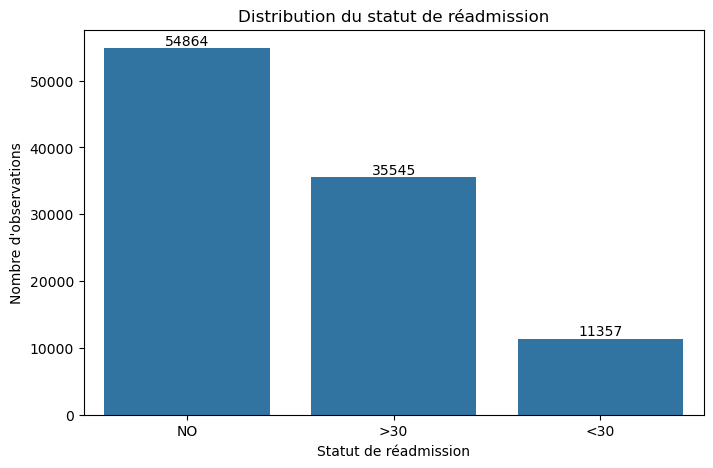

In [18]:
readmitted_counts = df["readmitted"].value_counts()
readmitted_percent = df["readmitted"].value_counts(normalize=True) * 100

readmitted_summary = pd.DataFrame({
    "Nombre": readmitted_counts,
    "Pourcentage": readmitted_percent.round(2)
})

display(readmitted_summary)

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="readmitted",
    order=readmitted_counts.index
)

plt.title("Distribution du statut de réadmission")
plt.xlabel("Statut de réadmission")
plt.ylabel("Nombre d'observations")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Interprétation

**Observation explicite :**
La variable `readmitted` présente trois catégories : `<30`, `>30` et `NO`.
La distribution montre que les catégories ne sont pas représentées dans les mêmes proportions. La catégorie majoritaire est `NO` (54 864 observations, soit 53,91 %), tandis que la catégorie minoritaire est `<30` (11 357 observations, soit 11,16 %). La catégorie `>30` représente 35 545 observations (34,93 %).

**Interprétation implicite :**
Cette répartition met en évidence un **déséquilibre entre les classes**. Ce déséquilibre devra être pris en compte lors de la classification, car un modèle pourrait obtenir une bonne accuracy tout en identifiant moins correctement les classes minoritaires.

**Pertinence de la variable :**
`readmitted` constitue la **variable cible** de notre problématique de classification. Elle ne sera donc pas utilisée comme variable explicative dans la segmentation, afin d'éviter de construire les clusters à partir du résultat que nous souhaitons ensuite étudier.

**Relation avec les autres variables :**
La distribution de `readmitted` servira de référence pour comparer ensuite certaines caractéristiques des séjours selon les différents statuts de réadmission.


## 2.2.3 Distribution de l'âge

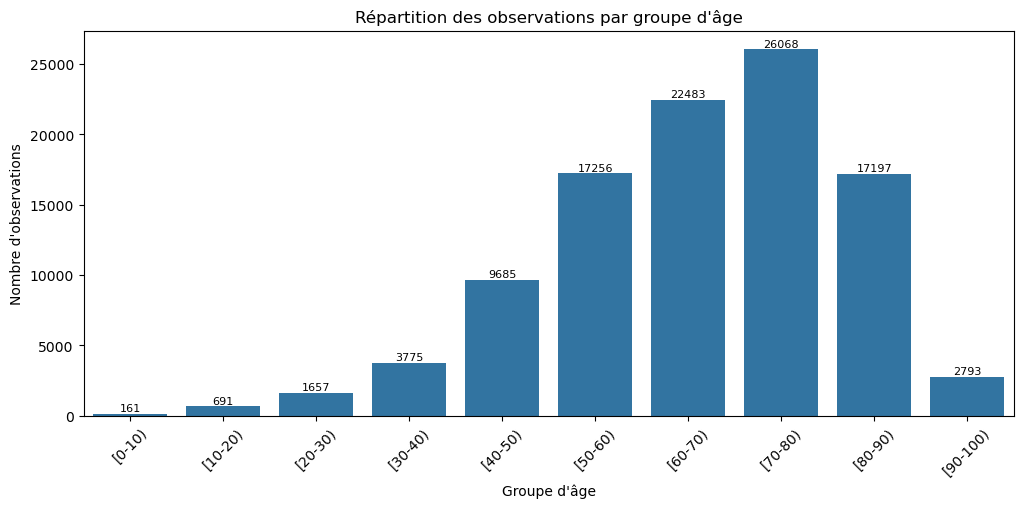

Groupe d'âge le plus représenté : [70-80)
Nombre d'observations : 26068


In [19]:
plt.figure(figsize=(12, 5))

age_order = sorted(
    df["age"].dropna().unique(),
    key=lambda x: int(x.strip("[]()").split("-")[0])
)

age_counts = df["age"].value_counts()

ax = sns.countplot(
    data=df,
    x="age",
    order=age_order
)

plt.title("Répartition des observations par groupe d'âge")
plt.xlabel("Groupe d'âge")
plt.ylabel("Nombre d'observations")
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, fontsize=8)

plt.show()

print("Groupe d'âge le plus représenté :", age_counts.idxmax())
print("Nombre d'observations :", age_counts.max())

### Interprétation

**Observation explicite :**  
La distribution montre que les observations sont concentrées dans certains
groupes d'âge. Le groupe [70-80) est le plus représenté (26 068 observations), tandis que
les groupes [0-10) et [10-20) sont moins fréquents (respectivement 161 et 691 observations). On observe également une tendance globale : la population est majoritairement âgée, avec une forte concentration entre 50 et 90 ans.

**Interprétation implicite :**  
La population étudiée est donc principalement représentée par certaines
tranches d'âge. Cette concentration peut influencer les modèles si certaines
catégories sont très peu représentées.

**Pertinence de la variable :**  
L'âge constitue une variable importante pour caractériser les profils de
patients. Il pourra donc contribuer à la segmentation et être utilisé comme
variable explicative dans la classification.

**Relation avec la cible :**  
À ce stade, la distribution seule ne permet pas de conclure que l'âge est
associé à la réadmission. Cette relation devra être étudiée en comparant les
groupes d'âge selon `readmitted`.

## 2.2.4 Durée d'hospitalisation

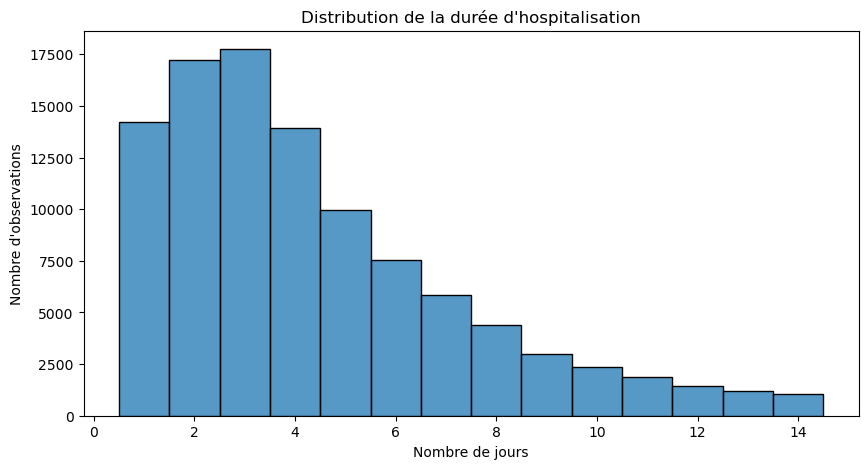

Médiane : 4.0
Moyenne : 4.4
Minimum : 1
Maximum : 14


In [20]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="time_in_hospital",
    bins=14,
    discrete=True
)

plt.title("Distribution de la durée d'hospitalisation")
plt.xlabel("Nombre de jours")
plt.ylabel("Nombre d'observations")

plt.show()

print("Médiane :", df["time_in_hospital"].median())
print("Moyenne :", round(df["time_in_hospital"].mean(), 2))
print("Minimum :", df["time_in_hospital"].min())
print("Maximum :", df["time_in_hospital"].max())

### Interprétation

**Observation explicite :**  
La durée d'hospitalisation varie entre 1 et 14 jours.
La distribution est principalement concentrée autour de 2 à 4 jours,
avec une médiane de 4.0 jours.

**Interprétation implicite :**  
La concentration des observations sur certaines durées indique que les séjours
très courts ou très longs sont moins représentés. Les éventuelles valeurs
extrêmes doivent néanmoins être interprétées avec prudence, car elles peuvent
correspondre à des situations hospitalières réelles.

**Pertinence de la variable :**  
`time_in_hospital` constitue un indicateur de la durée et potentiellement de
la complexité du séjour. Elle est donc pertinente pour différencier les
profils de patients lors du clustering.

**Relation avec la réadmission :**  
Une différence de durée entre les groupes de réadmission pourrait indiquer une
association entre ces variables. Cependant, cette observation ne permet pas
d'établir une relation causale.

## 2.2.5 Nombre de médicaments

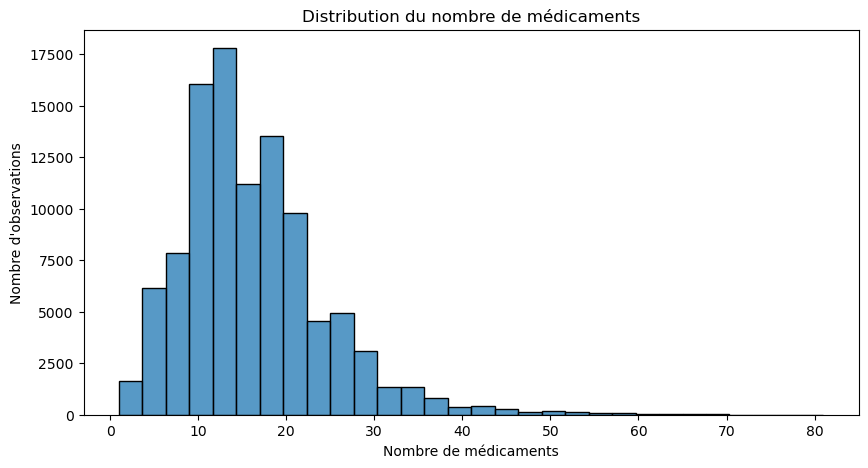

Médiane : 15.0
Moyenne : 16.02
Minimum : 1
Maximum : 81


In [21]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="num_medications",
    bins=30
)

plt.title("Distribution du nombre de médicaments")
plt.xlabel("Nombre de médicaments")
plt.ylabel("Nombre d'observations")

plt.show()

print("Médiane :", df["num_medications"].median())
print("Moyenne :", round(df["num_medications"].mean(), 2))
print("Minimum :", df["num_medications"].min())
print("Maximum :", df["num_medications"].max())

### Interprétation

**Observation explicite :**  
Le nombre de médicaments présente une distribution étendue, avec une
concentration des observations autour de 10 à 20 médicaments (avec un pic marqué vers 13-15). Les valeurs
extrêmes correspondent aux séjours comportant un nombre particulièrement
important de médicaments (allant de 1 à 81).

**Interprétation implicite :**  
Cette dispersion traduit une hétérogénéité dans les parcours de soins. Certains
patients présentent un traitement relativement limité tandis que d'autres
présentent des prises en charge plus complexes.

**Pertinence de la variable :**  
`num_medications` est particulièrement intéressante pour la segmentation car
elle peut contribuer à différencier des profils de patients selon la
complexité de leur prise en charge.

**Relation avec la cible :**  
La comparaison de cette variable selon `readmitted` permettra de déterminer
si les différents statuts de réadmission présentent des distributions
différentes.

## 2.2.6 Visites précédentes

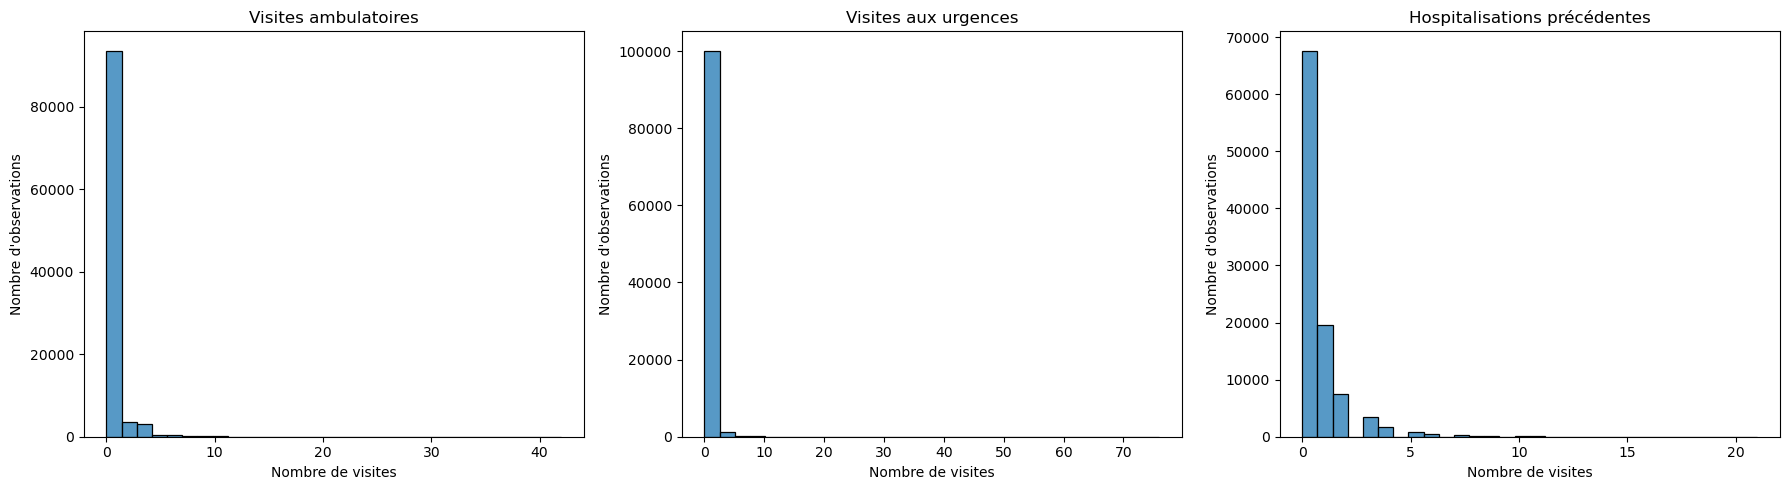

Médianes :


,Médiane
number_outpatient,0.0
number_emergency,0.0
number_inpatient,0.0



Maximums :


,Maximum
number_outpatient,42
number_emergency,76
number_inpatient,21


In [22]:
previous_visit_cols = [
    "number_outpatient",
    "number_emergency",
    "number_inpatient"
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

titles = [
    "Visites ambulatoires",
    "Visites aux urgences",
    "Hospitalisations précédentes"
]

for ax, col, title in zip(
    axes,
    previous_visit_cols,
    titles
):
    sns.histplot(
        df[col],
        bins=30,
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel("Nombre de visites")
    ax.set_ylabel("Nombre d'observations")

plt.tight_layout()
plt.show()

print("Médianes :")
display(df[previous_visit_cols].median().to_frame("Médiane"))

print("\nMaximums :")
display(df[previous_visit_cols].max().to_frame("Maximum"))

### Interprétation

**Observation explicite :**
Les trois distributions (`number_outpatient`, `number_emergency`, `number_inpatient`) sont fortement concentrées autour de **0 visite**, avec des médianes égales à 0. Les valeurs maximales sont relativement élevées (42, 76 et 21), ce qui montre la présence de quelques observations présentant un nombre important de visites précédentes.

**Interprétation implicite :**
Une grande proportion des séjours présente donc peu ou pas de recours antérieur aux soins dans chacune des catégories étudiées, tandis que certaines observations présentent un historique de visites plus important. Ces valeurs élevées pourront être examinées plus précisément lors de l'analyse des valeurs atypiques.

**Pertinence pour le clustering :**
Ces trois variables décrivent différentes dimensions du recours antérieur aux soins. Elles pourront contribuer à identifier des profils de séjours présentant des historiques de recours aux soins différents.

**Pertinence pour la classification :**
Ces variables pourront être étudiées comme des caractéristiques potentiellement liées au statut de réadmission. Leur relation avec `readmitted` sera analysée dans une étape ultérieure.

**Relation entre variables :**
Les trois variables décrivent des types différents de recours aux soins : visites ambulatoires, visites aux urgences et hospitalisations précédentes. Leur combinaison peut donc fournir une description plus complète de l'historique de recours aux soins qu'une seule variable prise isolément.


## 2.2.7 Réadmission selon la durée d'hospitalisation

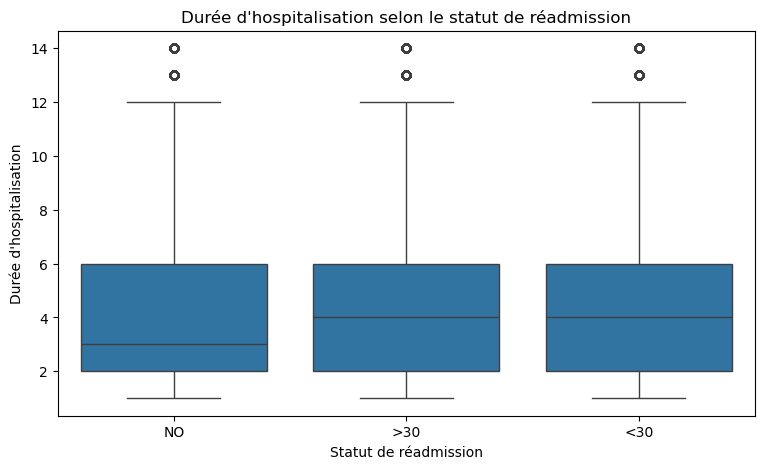

            count  mean  median  min  max
readmitted                               
<30         11357  4.77     4.0    1   14
>30         35545  4.50     4.0    1   14
NO          54864  4.25     3.0    1   14


In [23]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="readmitted",
    y="time_in_hospital"
)

plt.title("Durée d'hospitalisation selon le statut de réadmission")
plt.xlabel("Statut de réadmission")
plt.ylabel("Durée d'hospitalisation")

plt.show()

print(
    df.groupby("readmitted")["time_in_hospital"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

### Interprétation

**Observation explicite :**
Les trois groupes de réadmission (`NO`, `>30`, `<30`) présentent des distributions de durée d'hospitalisation globalement similaires : les médianes sont proches (3 à 4 jours), les intervalles interquartiles sont comparables et le maximum est identique (14 jours). Les moyennes restent également proches : 4,25 jours pour `NO`, 4,50 jours pour `>30` et 4,77 jours pour `<30`.

**Interprétation implicite :**
On observe une légère tendance descriptive : la durée moyenne d'hospitalisation est un peu plus élevée pour les séjours associés à une réadmission précoce (`<30`). Cependant, les distributions se chevauchent fortement, ce qui montre que les différences entre les groupes restent limitées. La variable `time_in_hospital` ne permet donc pas, à elle seule, de distinguer clairement les trois catégories de réadmission.

**Pertinence pour le clustering :**
La durée du séjour reste une variable utile pour la segmentation, car elle décrit une caractéristique importante du séjour hospitalier et peut contribuer à différencier certains profils.

**Relation avec la cible :**
La durée d'hospitalisation présente des différences descriptives limitées selon le statut de réadmission. Cette variable devra donc être étudiée avec d'autres caractéristiques, telles que les médicaments, les diagnostics et les antécédents de visites, afin d'obtenir une vision plus complète des profils associés à la réadmission.


## 2.2.8 Réadmission selon le nombre de médicaments

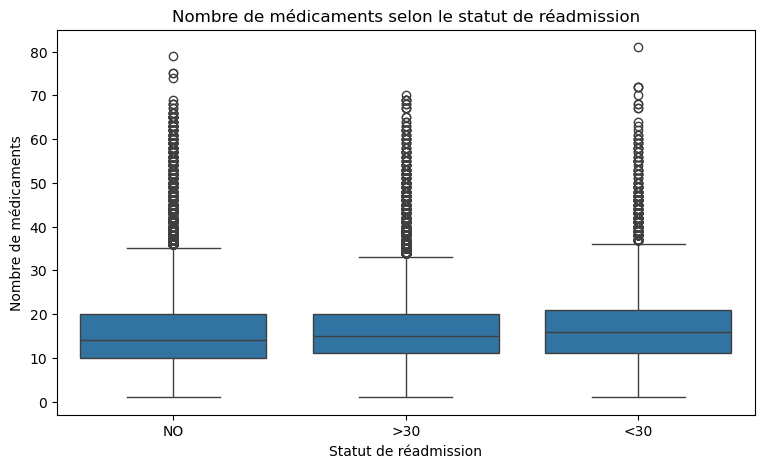

            count   mean  median  min  max
readmitted                                
<30         11357  16.90    16.0    1   81
>30         35545  16.28    15.0    1   70
NO          54864  15.67    14.0    1   79


In [24]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="readmitted",
    y="num_medications"
)

plt.title("Nombre de médicaments selon le statut de réadmission")
plt.xlabel("Statut de réadmission")
plt.ylabel("Nombre de médicaments")

plt.show()

print(
    df.groupby("readmitted")["num_medications"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

### Interprétation

**Observation explicite :**
Les trois groupes de réadmission présentent des distributions du nombre de médicaments très proches. Les médianes sont légèrement croissantes : 14 (NO), 15 (>30) et 16 (<30). Les moyennes suivent la même tendance : 15,67 (NO), 16,28 (>30) et 16,90 (<30). Les boîtes sont largement chevauchées et de nombreux outliers sont visibles pour les trois classes (jusqu'à 81 médicaments).

**Interprétation implicite :**
On observe une légère tendance : plus la réadmission est précoce, plus le nombre de médicaments a tendance à être élevé. Cela suggère que les patients réadmis tôt ont des traitements plus lourds, donc potentiellement des pathologies plus complexes. Cependant, la différence reste faible et le fort chevauchement indique que cette variable seule ne suffit pas à distinguer les classes.

**Pertinence pour le clustering :**
`num_medications` reste une variable utile pour la segmentation, car elle reflète indirectement la complexité de la prise en charge.

**Relation avec la cible :**
L'association entre nombre de médicaments et statut de réadmission est faible mais cohérente (plus de médicaments → réadmission plus précoce). Elle ne doit pas être interprétée comme causale, mais elle devra être combinée à d'autres variables pour améliorer la prédiction.

## 2.2.9 Matrice de corrélation


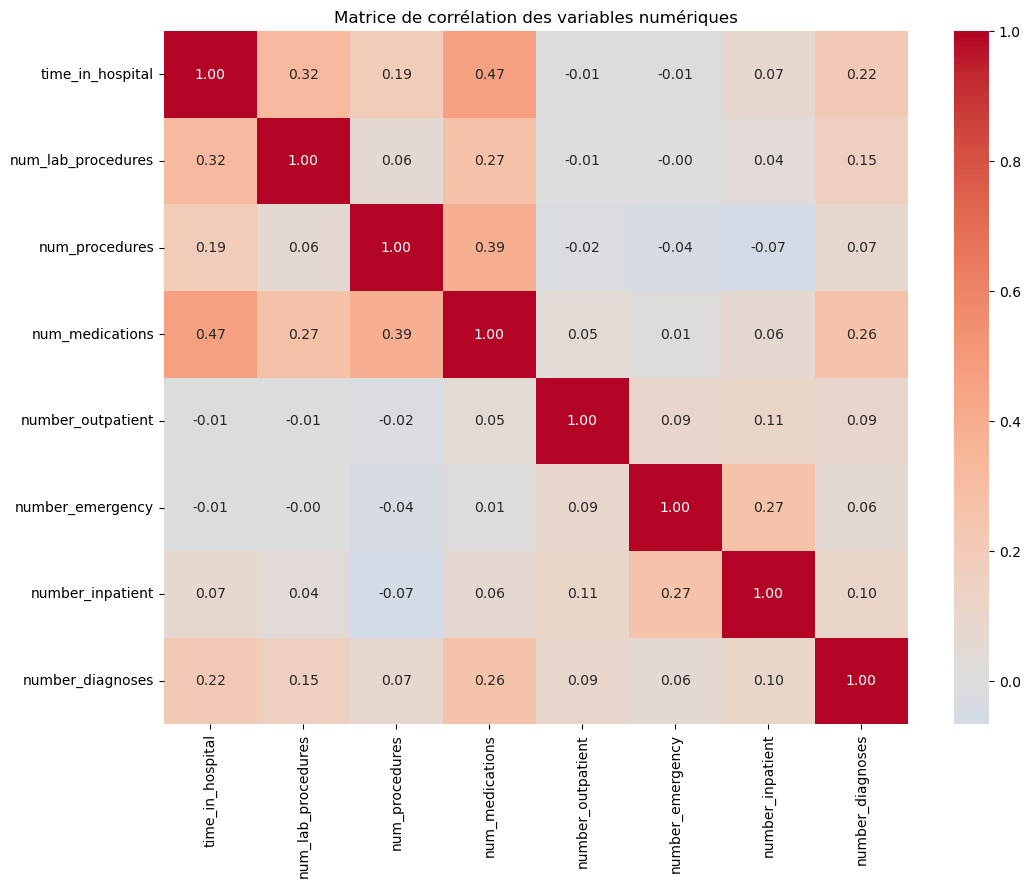

In [25]:
# Variables numériques pertinentes pour l'exploration
correlation_cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

correlation_matrix = df[correlation_cols].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matrice de corrélation des variables numériques")

plt.show()

### Interprétation

**Observation explicite :**
La matrice met en évidence plusieurs niveaux de corrélation entre les variables numériques. Certaines relations sont faibles, tandis que certaines variables présentent des corrélations positives plus visibles. Les corrélations les plus fortes sont observées entre `num_medications` et `time_in_hospital` (0,47), entre `num_procedures` et `num_medications` (0,39), ainsi qu'entre `num_lab_procedures` et `time_in_hospital` (0,32). À l'inverse, les variables `number_outpatient` et `number_emergency` présentent des corrélations très faibles, voire négatives, avec les autres variables.

**Interprétation implicite :**
Une corrélation positive signifie que les deux variables ont tendance à évoluer dans le même sens dans les observations étudiées. Par exemple, une durée d'hospitalisation plus longue est généralement associée à un nombre de médicaments plus élevé et à un nombre plus important de procédures de laboratoire. Une corrélation faible indique au contraire que la relation linéaire entre les deux variables est limitée.

**Pertinence pour le clustering :**
Cette analyse permet d'identifier les variables qui apportent des informations différentes et celles qui pourraient être partiellement redondantes. Les corrélations modérées observées (autour de 0,4 à 0,5) ne justifient pas à elles seules la suppression de variables, mais elles indiquent que `time_in_hospital`, `num_medications` et `num_lab_procedures` partagent une partie de leur information. Cette analyse pourra donc aider à préparer la sélection des variables utilisées pour la segmentation.

**Pertinence pour la classification :**
La matrice permet également de repérer d'éventuelles relations entre les variables explicatives. Aucune corrélation forte n'est observée entre les variables étudiées, puisque la valeur maximale est de 0,47. Cette analyse ne met donc pas en évidence une forte redondance linéaire entre ces variables. La multicolinéarité pourra néanmoins être vérifiée plus précisément lors de la préparation et de la modélisation.

**Relation entre variables :**
Les corrélations observées décrivent uniquement des associations linéaires. Elles ne permettent pas de conclure qu'une variable provoque une variation de l'autre. Par exemple, on ne peut pas affirmer que la prise de médicaments allonge la durée de séjour ; on observe seulement que ces deux variables ont tendance à évoluer dans le même sens.

Cette analyse constitue donc une étape exploratoire et sera complétée par les étapes de préparation des données et par les résultats des modèles de Machine Learning.


## 2.2.10 Réadmission selon les hospitalisations précédentes


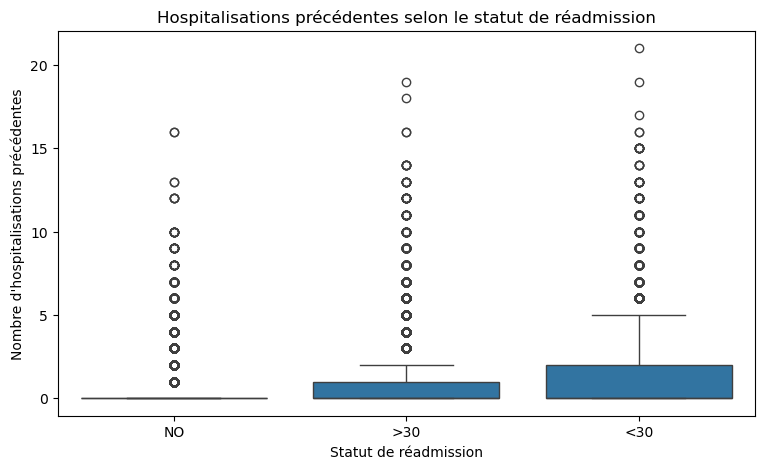

            count  mean  median  max
readmitted                          
<30         11357  1.22     0.0   21
>30         35545  0.84     0.0   19
NO          54864  0.38     0.0   16


In [26]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="readmitted",
    y="number_inpatient"
)

plt.title("Hospitalisations précédentes selon le statut de réadmission")
plt.xlabel("Statut de réadmission")
plt.ylabel("Nombre d'hospitalisations précédentes")

plt.show()

print(
    df.groupby("readmitted")["number_inpatient"]
    .agg(["count", "mean", "median", "max"])
    .round(2)
)

### Interprétation

**Observation explicite :**
Les médianes sont nulles pour les trois groupes, mais les moyennes diffèrent : 0,38 pour `NO`, 0,84 pour `>30` et **1,22 pour `<30`**. La distribution du groupe `<30` présente également un troisième quartile plus élevé (Q3 ≈ 2) que celui des groupes `>30` (Q3 ≈ 1) et `NO` (Q3 ≈ 0). Les valeurs maximales sont également plus élevées pour `<30` (21), suivi de `>30` (19) et de `NO` (16).

**Interprétation implicite :**
On observe une tendance descriptive selon laquelle les séjours associés à une réadmission précoce (`<30`) présentent en moyenne davantage d'hospitalisations précédentes que les séjours `>30` ou `NO`. La médiane égale à 0 dans les trois groupes montre cependant que les distributions sont fortement concentrées autour de zéro. Les différences de moyenne sont donc notamment influencées par les observations présentant plusieurs hospitalisations précédentes.

**Pertinence pour le clustering :**
`number_inpatient` peut contribuer à distinguer différents profils de séjours selon leur historique d'hospitalisations précédentes. Par exemple, cette variable permet de différencier des séjours avec peu ou aucune hospitalisation précédente de ceux présentant un historique d'hospitalisations plus important.

**Relation avec la cible :**
La variable `number_inpatient` présente des différences descriptives entre les trois catégories de `readmitted`, avec une moyenne plus élevée pour la classe `<30`. Elle constitue donc une variable intéressante à conserver pour les étapes suivantes de préparation et de modélisation. Son importance réelle pour la classification sera évaluée avec les performances et l'interprétation des modèles. Cette association ne doit pas être interprétée comme une relation causale.


## 2.2.11 Analyse des valeurs manquantes ('?' et NaN)

,Nb '?',Nb NaN,Total manquant,% manquant
weight,0,98569,98569,96.86
max_glu_serum,0,96420,96420,94.75
A1Cresult,0,84748,84748,83.28
medical_specialty,0,49949,49949,49.08
payer_code,0,40256,40256,39.56
race,0,2273,2273,2.23
diag_3,0,1423,1423,1.40
diag_2,0,358,358,0.35
diag_1,0,21,21,0.02


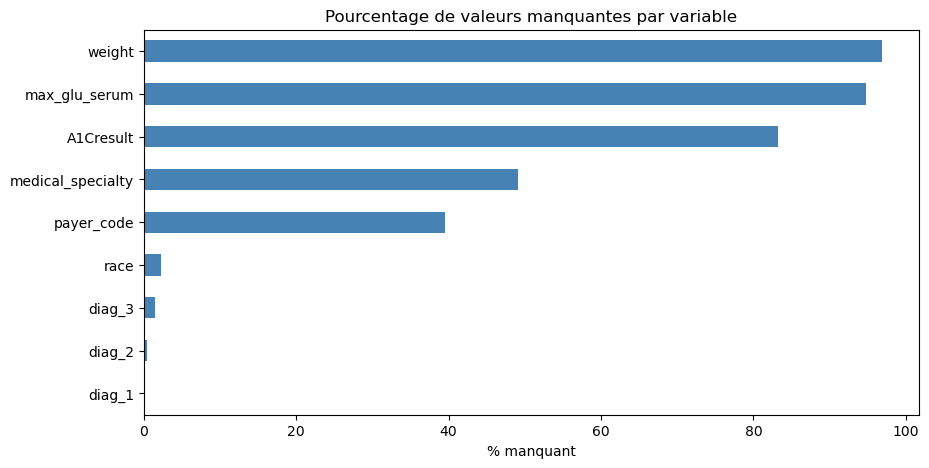

In [27]:
# --- Valeurs '?' par colonne ---
missing_question = (df == "?").sum()
missing_question = missing_question[missing_question > 0]

# --- Vraies valeurs NaN ---
missing_nan = df.isna().sum()
missing_nan = missing_nan[missing_nan > 0]

# --- Combinaison des deux (avec réindexation propre) ---
all_cols = missing_question.index.union(missing_nan.index)

missing_summary = pd.DataFrame({
    "Nb '?'": missing_question.reindex(all_cols, fill_value=0),
    "Nb NaN": missing_nan.reindex(all_cols, fill_value=0)
})

missing_summary["Total manquant"] = missing_summary["Nb '?'"] + missing_summary["Nb NaN"]
missing_summary["% manquant"] = (missing_summary["Total manquant"] / len(df) * 100).round(2)

missing_summary = missing_summary.sort_values("% manquant", ascending=False)

display(missing_summary)

# --- Visualisation ---
plt.figure(figsize=(10, 5))
missing_summary["% manquant"].plot(kind="barh", color="steelblue")
plt.title("Pourcentage de valeurs manquantes par variable")
plt.xlabel("% manquant")
plt.gca().invert_yaxis()
plt.show()

### Interprétation

**Observation explicite :**
Trois variables présentent un taux de valeurs manquantes très élevé :
- `weight` : **96,86 %** (98 569 valeurs codées `?`)
- `max_glu_serum` : **94,75 %** (96 420 NaN)
- `A1Cresult` : **83,28 %** (84 748 NaN)

Deux variables présentent un taux modéré :
- `medical_specialty` : **49,08 %** (49 949 valeurs `?`)
- `payer_code` : **39,56 %** (40 256 valeurs `?`)

Quatre variables ont un taux faible :
- `race` : 2,23 % — `diag_3` : 1,40 % — `diag_2` : 0,35 % — `diag_1` : 0,02 %

**Interprétation implicite :**
Les trois premières variables sont trop incomplètes pour être exploitées de manière fiable : elles apporteraient plus de bruit que d'information. Les deux suivantes peuvent être conservées en créant une modalité "Inconnu". Les diagnostics et la race peuvent être traités sans perte majeure vu leur très faible taux de manquants.

**Pertinence pour la Data Preparation :**
- **Suppression** des colonnes : `weight`, `max_glu_serum`, `A1Cresult` (> 80 % manquants)
- **Imputation par "Inconnu"** : `medical_specialty`, `payer_code`
- **Traitement léger** : `race`, `diag_1/2/3` (suppression des lignes ou imputation)

## 2.2.12 Analyse des doublons (lignes + patients)

In [28]:
# --- Doublons de lignes complètes ---
duplicated_rows = df.duplicated().sum()
print("Nombre de lignes strictement dupliquées :", duplicated_rows)

# --- Doublons patients (plusieurs séjours pour un même patient) ---
duplicated_patients = df["patient_nbr"].duplicated().sum()
print("Nombre de séjours en doublon patient :", duplicated_patients)

# --- Nombre de patients uniques vs séjours ---
print("Nombre de patients uniques :", df["patient_nbr"].nunique())
print("Nombre total de séjours :", len(df))

# --- Distribution du nombre de séjours par patient ---
sejours_par_patient = df["patient_nbr"].value_counts()
print("\nNombre de patients avec plusieurs séjours :",
      (sejours_par_patient > 1).sum())

# --- Aperçu des patients les plus fréquents ---
display(sejours_par_patient.head(10).to_frame("Nb séjours"))

Nombre de lignes strictement dupliquées : 0
Nombre de séjours en doublon patient : 30248
Nombre de patients uniques : 71518
Nombre total de séjours : 101766

Nombre de patients avec plusieurs séjours : 16773


,Nb séjours
patient_nbr,
88785891,40
43140906,28
1660293,23
88227540,23
23199021,23
23643405,22
84428613,22
92709351,21
88789707,20


### Interprétation

**Observation explicite :**
Aucune ligne dupliquée, mais **30 248 séjours en doublon patient** pour **71 518 patients uniques** et **101 766 séjours**. **16 773 patients** ont plusieurs séjours (jusqu'à 40 pour un même patient).

**Interprétation implicite :**
Le dataset est organisé par séjour, pas par patient. Un même patient peut apparaître de nombreuses fois, ce qui crée une dépendance entre les lignes.

**Pertinence pour la Data Preparation :**
Risque de **data leakage** si le split train/test est naïf. Deux options : conserver un seul séjour par patient, ou utiliser un **GroupShuffleSplit** basé sur `patient_nbr`.

## 2.2.13 Analyse des colonnes constantes / quasi-constantes


Nombre de colonnes constantes : 2

Colonnes constantes :
citoglipton    1
examide        1
dtype: int64

Colonnes avec le moins de modalités :


,Nb modalités
citoglipton,1
examide,1
troglitazone,2
change,2
metformin-pioglitazone,2
metformin-rosiglitazone,2
glimepiride-pioglitazone,2
glipizide-metformin,2
acetohexamide,2
tolbutamide,2


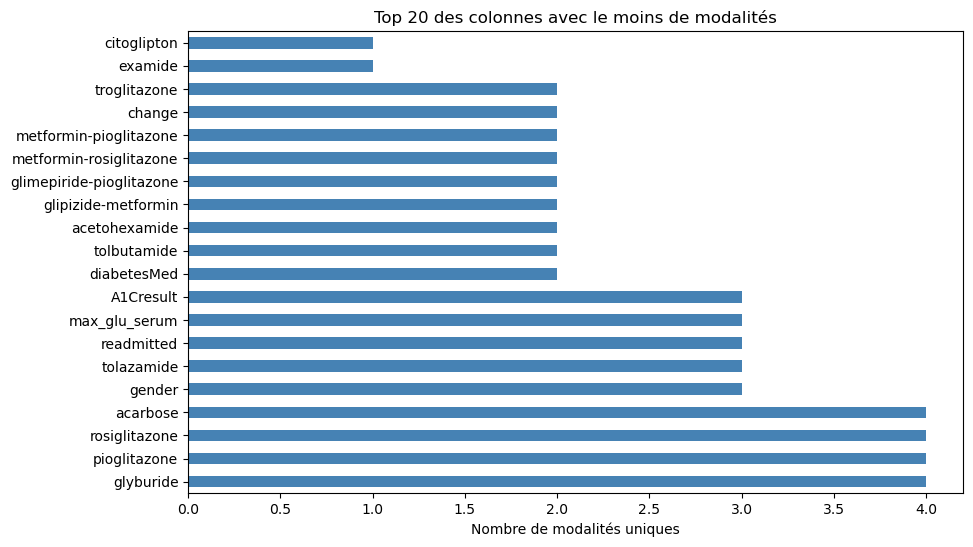

In [29]:
# --- Nombre de modalités par colonne ---
nunique = df.nunique().sort_values()

# --- Colonnes à 1 seule modalité (constantes) ---
const_cols = nunique[nunique == 1]
print("Nombre de colonnes constantes :", len(const_cols))
print("\nColonnes constantes :")
print(const_cols)

# --- Colonnes avec très faible variabilité (top 15) ---
print("\nColonnes avec le moins de modalités :")
display(nunique.head(15).to_frame("Nb modalités"))

# --- Visualisation ---
plt.figure(figsize=(10, 6))
nunique.head(20).plot(kind="barh", color="steelblue")
plt.title("Top 20 des colonnes avec le moins de modalités")
plt.xlabel("Nombre de modalités uniques")
plt.gca().invert_yaxis()
plt.show()

### Interprétation

**Observation explicite :**
Deux colonnes sont **strictement constantes** : `citoglipton` et `examide` (1 seule modalité). Plusieurs autres ont **2 modalités** : `acetohexamide`, `glipizide-metformin`, `tolbutamide`, `troglitazone`, `metformin-rosiglitazone`, `glimepiride-pioglitazone`, `metformin-pioglitazone`, `change` et `diabetesMed`.

**Interprétation implicite :**
Les colonnes constantes n'apportent aucune information discriminante. Les colonnes à 2 modalités avec une distribution très déséquilibrée (ex. un médicament prescrit chez <1 % des patients) sont quasi-constantes et donc également peu informatives.

**Pertinence pour la Data Preparation :**
- **Suppression systématique** des colonnes constantes : `citoglipton`, `examide`.
- **Vérification de la distribution** des colonnes à 2 modalités avant décision : celles dont une modalité dépasse 99 % pourront aussi être supprimées.

## 2.2.14 Détection des outliers (IQR)


,Variable,Q1,Q3,IQR,Borne inf.,Borne sup.,Nb outliers,% outliers
0,time_in_hospital,2.0,6.0,4.0,-4.0,12.0,2252,2.21
1,num_lab_procedures,31.0,57.0,26.0,-8.0,96.0,143,0.14
2,num_procedures,0.0,2.0,2.0,-3.0,5.0,4954,4.87
3,num_medications,10.0,20.0,10.0,-5.0,35.0,2557,2.51
4,number_outpatient,0.0,0.0,0.0,0.0,0.0,16739,16.45
5,number_emergency,0.0,0.0,0.0,0.0,0.0,11383,11.19
6,number_inpatient,0.0,1.0,1.0,-1.5,2.5,7049,6.93
7,number_diagnoses,6.0,9.0,3.0,1.5,13.5,281,0.28


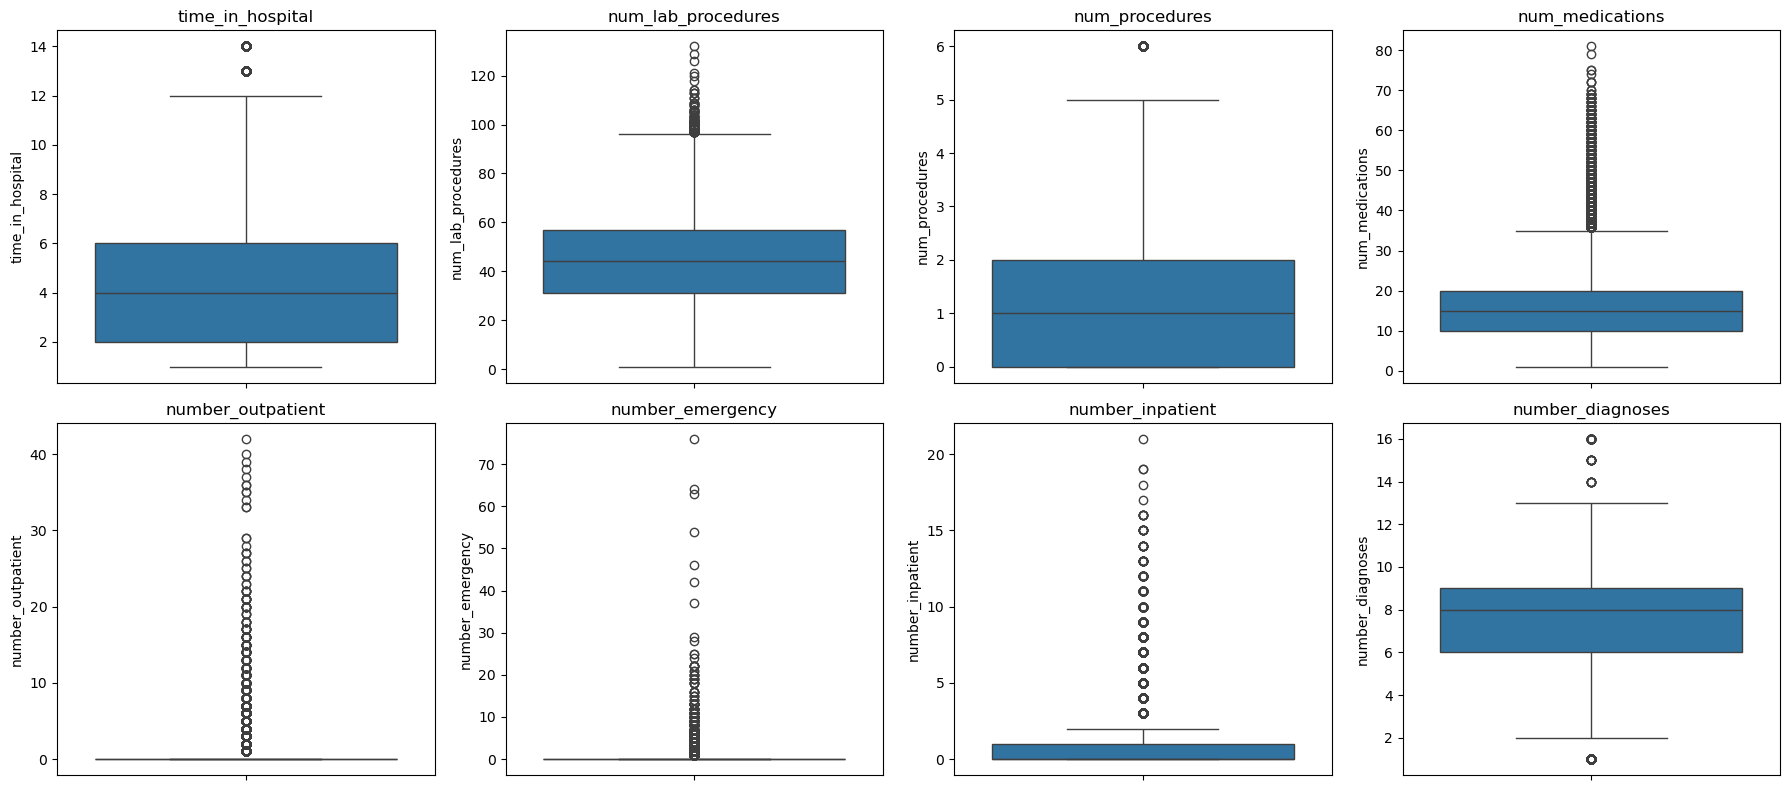

In [30]:
# --- Variables numériques continues à analyser ---
outlier_cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

# --- Détection par la méthode IQR ---
outlier_summary = []

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({
        "Variable": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Borne inf.": round(lower, 2),
        "Borne sup.": round(upper, 2),
        "Nb outliers": n_outliers,
        "% outliers": round(n_outliers / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)

# --- Boxplots ---
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), outlier_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

### Interprétation

**Observation explicite :**
La méthode IQR permet d'identifier des valeurs potentiellement atypiques dans plusieurs variables quantitatives. Les proportions les plus élevées sont observées pour les variables de comptage des visites précédentes :

* `number_outpatient` : **16,45 %**
* `number_emergency` : **11,19 %**
* `number_inpatient` : **6,93 %**
* `num_procedures` : **4,87 %**
* `num_medications` : **2,51 %**
* `time_in_hospital` : **2,21 %**

À l'inverse, `num_lab_procedures` (**0,14 %**) et `number_diagnoses` (**0,28 %**) présentent très peu de valeurs détectées comme atypiques.

**Interprétation implicite :**
Les variables `number_outpatient` et `number_emergency` ont un IQR nul (`Q1 = Q3 = 0`). Cela signifie qu'au moins 75 % des séjours ont une valeur égale à 0. Par conséquent, toute valeur supérieure à 0 est considérée comme atypique selon la règle IQR. Ces valeurs ne sont pas nécessairement des erreurs : elles peuvent correspondre à des séjours concernant des patients ayant eu davantage de visites ou de recours aux soins auparavant.

**Pertinence pour la Data Preparation :**
Les valeurs détectées comme atypiques ne seront pas supprimées automatiquement, car elles peuvent représenter des situations réelles. Leur traitement dépendra également de l'algorithme utilisé. Les méthodes basées sur les distances, comme **K-Means**, peuvent être sensibles aux valeurs extrêmes, tandis que certains modèles comme les **Random Forest** sont généralement moins sensibles à ce type de valeurs.

Une transformation ou une autre stratégie de traitement pourra donc être envisagée lors de la préparation finale des données si cela est nécessaire pour les modèles retenus.


# 3. Data Preparation


## Etape 1:  Data Cleaning

### 1. Identification des valeurs manquantes


La première étape du nettoyage consiste à identifier les valeurs manquantes dans le jeu de données. Les valeurs `?` présentes dans le fichier original ont été converties en `NaN` lors du chargement des données. Nous calculons ensuite le nombre et le pourcentage de valeurs manquantes pour chaque variable.


In [74]:
missing_percent = (df.isna().sum() / len(df) * 100).round(2)
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

display(missing_percent.to_frame("% de valeurs manquantes"))

,% de valeurs manquantes
weight,96.86
max_glu_serum,94.75
A1Cresult,83.28
medical_specialty,49.08
payer_code,39.56
race,2.23
diag_3,1.40
diag_2,0.35
diag_1,0.02


Interprétation

L’analyse montre que plusieurs variables présentent des valeurs manquantes. La variable weight possède le taux le plus élevé avec 96,86 %, suivie de max_glu_serum avec 94,75 % et de A1Cresult avec 83,28 %. medical_specialty et payer_code présentent également des taux importants, respectivement 49,08 % et 39,56 %.

En revanche, les variables race, diag_3, diag_2 et diag_1 présentent relativement peu de valeurs manquantes, avec des taux inférieurs à 3 %.

Ces résultats montrent que les variables ne peuvent pas toutes être traitées de la même manière. Le traitement sera donc choisi en fonction du taux de valeurs manquantes et de la nature de chaque variable.

### 2.  Traiter les colonnes avec énormément de valeurs manquantes

Certaines variables présentent un taux de valeurs manquantes très élevé. Leur imputation pourrait introduire beaucoup de valeurs artificielles et réduire la qualité de l'information. Nous supprimons donc les variables dont le taux de valeurs manquantes est particulièrement élevé.

In [6]:
df = df.drop(columns=["weight"])
df = df.drop(columns=["payer_code"])


#### Interprétation
La variable weight contient 96,86 % de valeurs manquantes, ce qui signifie que le poids du patient n’est pas renseigné pour la grande majorité des observations.

Avec un taux de données disponibles aussi faible, remplacer les valeurs manquantes par une valeur estimée risquerait de créer beaucoup de données artificielles et de diminuer la fiabilité de cette variable donc on la supprime plutôt

In [7]:
df["max_glu_serum"] = df["max_glu_serum"].fillna("Unknown")
df["A1Cresult"] = df["A1Cresult"].fillna("Unknown")
df["medical_specialty"] = df["medical_specialty"].fillna("Unknown")


print("max_glu_serum :", df["max_glu_serum"].isna().sum())
print("A1Cresult :", df["A1Cresult"].isna().sum())
print("medical_specialty :", df["medical_specialty"].isna().sum())


max_glu_serum : 0
A1Cresult : 0
medical_specialty : 0


#### Interprétation
Les valeurs manquantes ont été remplacées par `"Unknown"` afin de conserver ces variables sans inventer de valeurs. Après traitement, aucune valeur manquante ne reste dans ces quatre variables.


In [8]:
for col in ["race", "diag_1", "diag_2", "diag_3"]:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Nombre total de valeurs manquantes :", df.isna().sum().sum())


Nombre total de valeurs manquantes : 0


#### Interprétation
Les valeurs manquantes de race, diag_1, diag_2 et diag_3 ont été remplacées par leur valeur la plus fréquente (mode). Après ce traitement, le nombre total de valeurs manquantes est de 0, ce qui confirme que les données sont complètes.

Le nettoyage des données a permis de traiter l’ensemble des valeurs manquantes du dataset. La variable `weight`, présentant un taux très élevé de valeurs manquantes, a été supprimée. Pour `max_glu_serum`, `A1Cresult`, `medical_specialty` et `payer_code`, les valeurs manquantes ont été remplacées par `"Unknown"` afin de conserver ces variables. Enfin, les valeurs manquantes de `race`, `diag_1`, `diag_2` et `diag_3` ont été remplacées par leur valeur la plus fréquente. Après traitement, **aucune valeur manquante ne reste dans le dataset**.


### 3 Les doublons



In [9]:
print("Nombre de lignes dupliquées :", df.duplicated().sum())


Nombre de lignes dupliquées : 0


Interprétation :

La vérification des doublons montre qu’aucune ligne dupliquée n’est présente dans le dataset (**0 doublon**). Aucune suppression n’est donc nécessaire à ce niveau.


### 4 Outliers

Un outlier (valeur aberrante) est une valeur qui est très éloignée de la majorité des autres valeurs d’une variable.


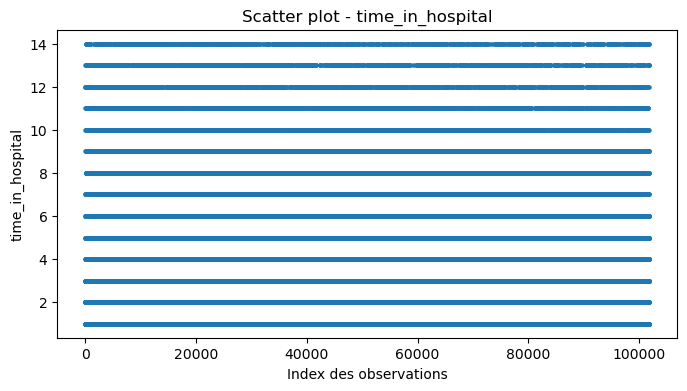

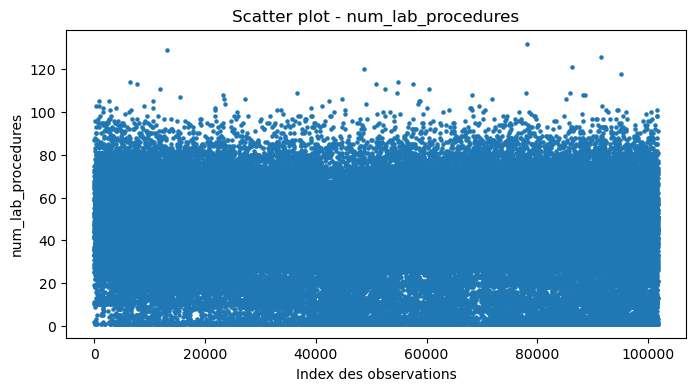

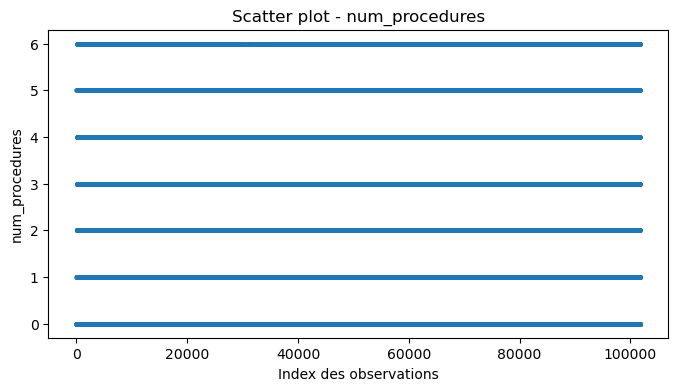

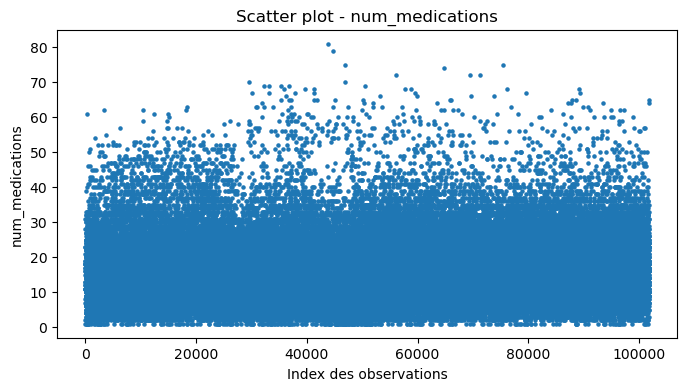

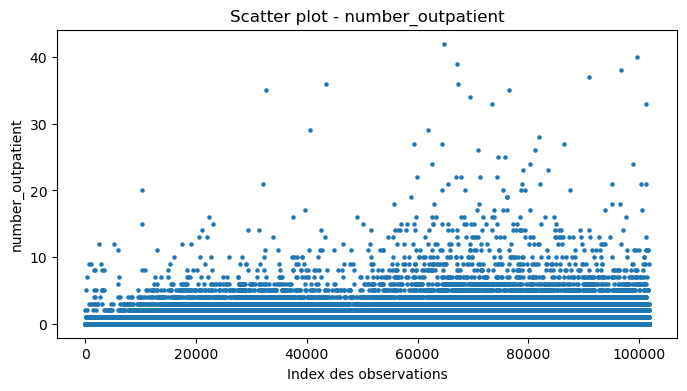

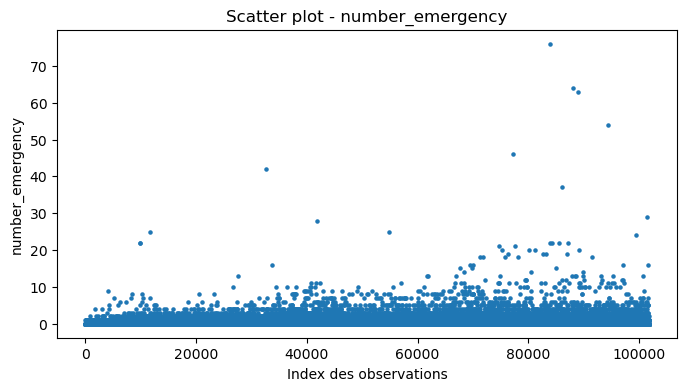

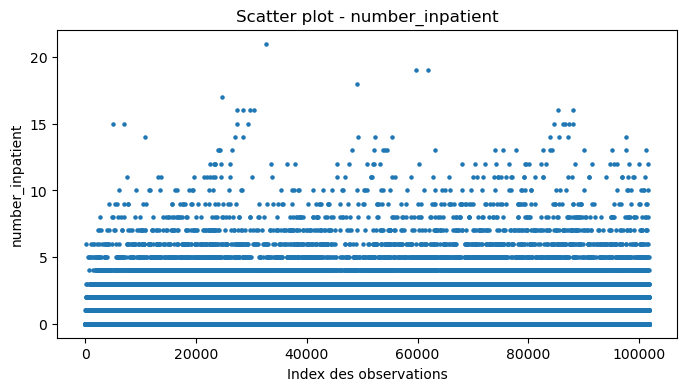

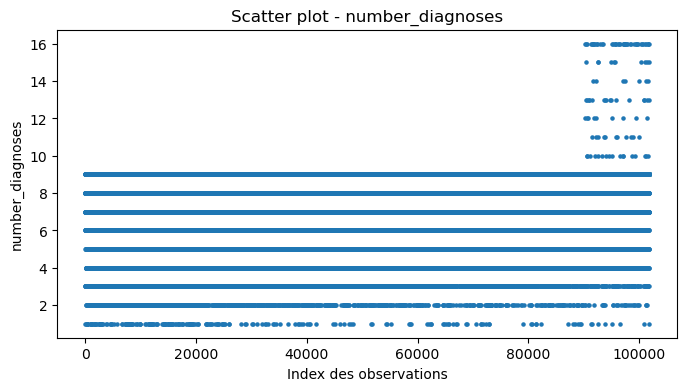

In [10]:
import matplotlib.pyplot as plt

numeric_cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    plt.scatter(range(len(df)), df[col], s=5)
    plt.title(f"Scatter plot - {col}")
    plt.xlabel("Index des observations")
    plt.ylabel(col)
    plt.show()

Interprétation :

Aucun traitement des outliers n’a été appliqué, car les valeurs identifiées sont possible  dans le contexte médical et peuvent contenir une information utile pour la prédiction de la réadmission.

### 3.1.5 Colonnes constantes

Identifier les colonnes qui ne contiennent qu'une seule valeur


In [80]:
nunique = df.nunique()

constant_cols = nunique[nunique == 1]

print("Colonnes constantes :")
print(constant_cols)

Colonnes constantes :
examide        1
citoglipton    1
dtype: int64


In [81]:
df = df.drop(columns=["examide", "citoglipton"])

Les colonnes examide et citoglipton ne contiennent qu’une seule valeur. Elles ont donc été supprimées car elles n’apportent aucune information utile à l’analyse et à la modélisation.

In [82]:
df.shape

(101766, 46)

## Étape 2 — Data Transformation

#### 1.Séparation des identifiants et de la variable cible

In [15]:
target_col = "readmitted"

X = df.drop(columns=[target_col, "encounter_id", "patient_nbr"])
y = df[target_col]

#### 2.Variables numériques et catégorielles
Mais avant de donner le code, on doit savoir exactement combien de variables catégorielles et numériques il reste dans X.

In [84]:
numeric_cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

categorical_cols = [
    col for col in X.columns
    if col not in numeric_cols
]

print("Variables quantitatives :", len(numeric_cols))
print("Variables catégorielles :", len(categorical_cols))

Variables quantitatives : 8
Variables catégorielles : 35


#### 3 Regroupement des diagnostics


In [16]:
def group_diagnosis(code):
    try:
        code = float(code)
    except (ValueError, TypeError):
        return "Other"

    if code == 250 or (250 < code < 251):
        return "Diabetes"
    elif 390 <= code <= 459 or code == 785:
        return "Circulatory"
    elif 460 <= code <= 519 or code == 786:
        return "Respiratory"
    elif 520 <= code <= 579 or code == 787:
        return "Digestive"
    elif 800 <= code <= 999:
        return "Injury"
    elif 710 <= code <= 739:
        return "Musculoskeletal"
    elif 580 <= code <= 629 or code == 788:
        return "Genitourinary"
    elif 140 <= code <= 239:
        return "Neoplasms"
    else:
        return "Other"

In [17]:
for col in ["diag_1", "diag_2", "diag_3"]:
    X[col + "_group"] = X[col].apply(group_diagnosis)

X = X.drop(columns=["diag_1", "diag_2", "diag_3"])

#### 4  Modalités rares

In [18]:
categorical_cols = X.select_dtypes(include="object").columns

threshold = 0.01 * len(X)

for col in categorical_cols:
    counts = X[col].value_counts()
    rare_values = counts[counts <= threshold].index
    X[col] = X[col].replace(rare_values, "Others")

#### 5 Encodage ordinal de age

In [19]:
from sklearn.preprocessing import OrdinalEncoder

age_order = [[
    "[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
    "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)",
    "Others"
]]

ord_enc = OrdinalEncoder(categories=age_order)

X["age"] = ord_enc.fit_transform(X[["age"]]).ravel()

print(X["age"].value_counts().sort_index())

age
2.0      1657
3.0      3775
4.0      9685
5.0     17256
6.0     22483
7.0     26068
8.0     17197
9.0      2793
10.0      852
Name: count, dtype: int64


#### 6 Encodage binaire

In [20]:
X["change"] = (X["change"] == "Ch").astype(int)
X["diabetesMed"] = (X["diabetesMed"] == "Yes").astype(int)

print("change :")
print(X["change"].value_counts())

print("\ndiabetesMed :")
print(X["diabetesMed"].value_counts())

change :
change
0    54755
1    47011
Name: count, dtype: int64

diabetesMed :
diabetesMed
1    78363
0    23403
Name: count, dtype: int64


#### 7 One-Hot Encoding

In [21]:
excluded_cols = numeric_cols + ["age", "change", "diabetesMed"]

nominal_cols = [
    col for col in X.columns
    if col not in excluded_cols
]

print("Nombre de variables nominales :", len(nominal_cols))

Nombre de variables nominales : 34


In [22]:
from sklearn.preprocessing import OneHotEncoder

onehot_enc = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_nominal_encoded = onehot_enc.fit_transform(
    X[nominal_cols]
)

print("Dimensions après One-Hot Encoding :", X_nominal_encoded.shape)

Dimensions après One-Hot Encoding : (101766, 159)


In [23]:
# Variables numériques + variables déjà encodées
X_numeric = X[numeric_cols + ["age", "change", "diabetesMed"]].reset_index(drop=True)

# Variables One-Hot encodées
X_nominal_encoded = pd.DataFrame(
    X_nominal_encoded,
    columns=onehot_enc.get_feature_names_out(nominal_cols)
).reset_index(drop=True)

# Fusion de toutes les variables
X_encoded = pd.concat(
    [X_numeric, X_nominal_encoded],
    axis=1
)

print("Dimensions finales :", X_encoded.shape)
print("Valeurs manquantes :", X_encoded.isna().sum().sum())
print("Variables non numériques :", X_encoded.select_dtypes(exclude="number").shape[1])

Dimensions finales : (101766, 170)
Valeurs manquantes : 0
Variables non numériques : 0


##  Étape 3 Feature Engineering

Le Feature Engineering consiste à créer de nouvelles variables à partir des variables existantes afin d’obtenir des informations plus synthétiques et potentiellement plus utiles pour la modélisation. Dans notre dataset, nous avons créé deux nouvelles variables liées à l’activité médicale du patient.

#### 1 Création de total_previous_visits

In [24]:
X["total_previous_visits"] = (
    X["number_outpatient"]
    + X["number_emergency"]
    + X["number_inpatient"]
)

print(X[[
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "total_previous_visits"
]].head())

   number_outpatient  number_emergency  number_inpatient  \
0                  0                 0                 0   
1                  0                 0                 0   
2                  2                 0                 1   
3                  0                 0                 0   
4                  0                 0                 0   

   total_previous_visits  
0                      0  
1                      0  
2                      3  
3                      0  
4                      0  


#### interpretation

La variable `total_previous_visits` représente le nombre total de visites antérieures du patient en combinant les visites ambulatoires, les passages aux urgences et les hospitalisations.


#### 2 Création de total_procedures

In [25]:
X["total_procedures"] = (
    X["num_lab_procedures"]
    + X["num_procedures"]
)

print(X[[
    "num_lab_procedures",
    "num_procedures",
    "total_procedures"
]].head())

   num_lab_procedures  num_procedures  total_procedures
0                  41               0                41
1                  59               0                59
2                  11               5                16
3                  44               1                45
4                  51               0                51


#### interpretation 
La variable `total_procedures` représente le nombre total de procédures réalisées pendant l’hospitalisation en combinant les procédures de laboratoire et les autres procédures médicales.


#### 3 Création de total_care_intensity

In [26]:
X["total_care_intensity"] = (
    X["num_lab_procedures"]
    + X["num_procedures"]
    + X["num_medications"]
)

print("Statistiques de total_care_intensity :")
display(X["total_care_intensity"].describe())

Statistiques de total_care_intensity :


count    101766.000000
mean         60.457216
std          23.588174
min           2.000000
25%          46.000000
50%          61.000000
75%          76.000000
max         179.000000
Name: total_care_intensity, dtype: float64

#### interpretation 
La variable `total_care_intensity` fournit une mesure synthétique de l’intensité des soins en combinant les procédures de laboratoire, les procédures médicales et le nombre de médicaments.


#### 4 Vérification finale du Feature Engineering

In [27]:
print("Nombre de variables après Feature Engineering :", X.shape[1])

print("\nNouvelles variables créées :")
print([
    "total_previous_visits",
    "total_procedures",
    "total_care_intensity"
])

Nombre de variables après Feature Engineering : 48

Nouvelles variables créées :
['total_previous_visits', 'total_procedures', 'total_care_intensity']


#### interpretation 
Trois nouvelles variables ont été créées à partir des variables existantes, faisant passer le nombre de variables de **43 à 46**. Le Feature Engineering est donc correctement réalisé.


##  Étape 4 Feature Selection

#### 1 Préparation des groupes

In [28]:
# 1. Préparation des groupes

numeric_features = numeric_cols + [
    "age",
    "change",
    "diabetesMed",
    "total_previous_visits",
    "total_procedures",
    "total_care_intensity"
]

X_numeric_fs = X[numeric_features].copy()

X_categorical_fs = pd.DataFrame(
    onehot_enc.transform(X[nominal_cols]),
    columns=onehot_enc.get_feature_names_out(nominal_cols)
)

print("Features numériques :", X_numeric_fs.shape[1])
print("Features catégorielles après encodage :", X_categorical_fs.shape[1])

Features numériques : 14
Features catégorielles après encodage : 159


#### 2.Calcul des scores du Chi²

In [98]:
from sklearn.feature_selection import SelectKBest, chi2

k_cat = 10

selector_chi2 = SelectKBest(
    score_func=chi2,
    k=k_cat
)

X_cat_selected = selector_chi2.fit_transform(
    X_categorical_fs,
    y
)

cat_selected_features = X_categorical_fs.columns[
    selector_chi2.get_support()
]

print("Features catégorielles sélectionnées :", len(cat_selected_features))
print(cat_selected_features.tolist())

Features catégorielles sélectionnées : 10
['admission_type_id_3', 'discharge_disposition_id_6', 'discharge_disposition_id_11', 'discharge_disposition_id_14', 'discharge_disposition_id_22', 'admission_source_id_4', 'admission_source_id_6', 'admission_source_id_7', 'insulin_Down', 'diag_1_group_Neoplasms']


####  3.Sélection des variables numériques avec Mutual Information

In [30]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(
    X_numeric_fs,
    y,
    random_state=42
)

mi_results = pd.DataFrame({
    "Feature": X_numeric_fs.columns,
    "Score_MI": mi_scores
})

mi_results = mi_results.sort_values(
    by="Score_MI",
    ascending=False
)

display(mi_results)

,Feature,Score_MI
11,total_previous_visits,0.029778
6,number_inpatient,0.029171
10,diabetesMed,0.010392
5,number_emergency,0.010204
7,number_diagnoses,0.009856
4,number_outpatient,0.008976
3,num_medications,0.005855
8,age,0.004837
9,change,0.004133
0,time_in_hospital,0.003876


Puis on garde les 10 meilleures :

In [35]:
top_numeric_features = mi_results.head(10)["Feature"].tolist()

print("Features numériques sélectionnées :", len(top_numeric_features))
print(top_numeric_features)

Features numériques sélectionnées : 10
['total_previous_visits', 'number_inpatient', 'diabetesMed', 'number_emergency', 'number_diagnoses', 'number_outpatient', 'num_medications', 'age', 'change', 'time_in_hospital']


Création du dataset final

In [34]:
X_selected_df = pd.concat(
    [
        X_numeric_fs[top_numeric_features].reset_index(drop=True),
        X_categorical_fs[cat_selected_features].reset_index(drop=True)
    ],
    axis=1
)

print("Dimensions finales :", X_selected_df.shape)

NameError: name 'cat_selected_features' is not defined

#### interpretation 
La Feature Selection a été réalisée en utilisant une méthode adaptée à chaque type de variable. Le test du Chi² a été appliqué aux variables catégorielles encodées, tandis que la Mutual Information a été utilisée pour les variables numériques. Les 10 meilleures features de chaque groupe ont été retenues, ce qui permet d’obtenir un ensemble final de 20 features pour la modélisation.


##  Étape 5 PCA

La PCA n’a pas été appliquée dans notre étude car la Feature Selection a déjà permis de réduire le nombre de features de **162 à 20**. Une réduction supplémentaire n’était donc pas nécessaire. De plus, la PCA transforme les variables originales en composantes principales, ce qui rend leur interprétation plus difficile. Nous avons donc conservé les 20 features sélectionnées afin de garder des variables directement interprétables.


##  Étape 6 Exportation du dataset final

In [102]:
from IPython.display import FileLink, display

# Ajouter la variable cible au dataset final
final_dataset = X_selected_df.copy()
final_dataset["readmitted"] = y.reset_index(drop=True)

# Vérification du dataset final
print("Dimensions du dataset final :", final_dataset.shape)
display(final_dataset.head())

# Sauvegarder en CSV
file_name = "diabetic_data_final.csv"
final_dataset.to_csv(file_name, index=False)

print("\nDataset final sauvegardé sous :", file_name)

# Afficher le lien de téléchargement
display(FileLink(file_name))

Dimensions du dataset final : (101766, 21)


,total_previous_visits,number_inpatient,diabetesMed,number_emergency,number_diagnoses,number_outpatient,num_medications,age,change,time_in_hospital,...,discharge_disposition_id_6,discharge_disposition_id_11,discharge_disposition_id_14,discharge_disposition_id_22,admission_source_id_4,admission_source_id_6,admission_source_id_7,insulin_Down,diag_1_group_Neoplasms,readmitted
0,0,0,0,0,1,0,1,10.0,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NO
1,0,0,1,0,9,0,18,10.0,1,3,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,>30
2,3,1,1,0,6,2,13,2.0,0,2,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,NO
3,0,0,1,0,7,0,16,3.0,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,NO
4,0,0,1,0,5,0,8,4.0,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,NO



Dataset final sauvegardé sous : diabetic_data_final.csv


C:\Users\ASUS\final ml\diabetic_data_final.csv

#  4. Modeling : Clustering & Classification

## 4.1 Clustering

#### 4.1.1 Problématique
Question métier : Existe-t-il des groupes homogènes de patients présentant des profils hospitaliers similaires ? Une segmentation permet d'adapter la prise en charge (suivi renforcé pour les profils lourds) et d'allouer les ressources de manière plus efficace.

Variables disponibles : après Data Preparation, le dataset final contient 10 features numériques sélectionnées par Mutual Information

#### 4.1.2 Préparation des données pour le clustering
Problème observé : K-Means est sensible à l'échelle des variables (distances euclidiennes). Or, total_previous_visits varie de 0 à plusieurs dizaines, tandis que age est encodé de 1 à 11. Sans standardisation, les variables à grande échelle domineraient.

Solution choisie : standardisation (z-score) de toutes les features numériques, fit sur le train uniquement.

Alternative écartée : Min-Max scaling — plus sensible aux outliers.

In [103]:
from sklearn.preprocessing import StandardScaler

# Colonnes numériques du dataset final
cols_cluster = ['total_previous_visits', 'number_inpatient', 'number_emergency',
                'number_diagnoses', 'number_outpatient', 'num_medications',
                'age', 'time_in_hospital']

scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(final_dataset[cols_cluster])

print("Données de clustering :", X_cluster.shape)

Données de clustering : (101766, 8)


#### 4.1.3 Choix du nombre de clusters K

,k,inertie,silhouette,davies_bouldin
0,2,678572.075,0.443,1.532
1,3,579944.423,0.193,1.611
2,4,517441.800,0.189,1.545
3,5,471594.105,0.199,1.503
4,6,430566.942,0.205,1.335
5,7,401552.456,0.174,1.357
6,8,375818.282,0.195,1.273
7,9,354559.885,0.184,1.249
8,10,334183.436,0.180,1.239


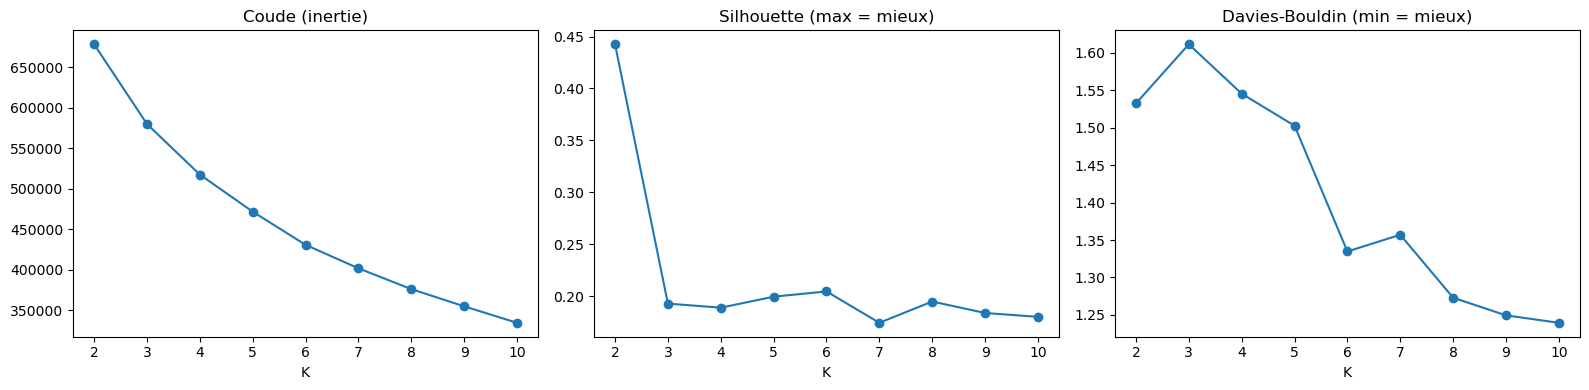

In [105]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

inerties, silhouettes, db_scores = [], [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_cluster)
    inerties.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster, km.labels_, sample_size=10000, random_state=42))
    db_scores.append(davies_bouldin_score(X_cluster, km.labels_))

res_k = pd.DataFrame({'k': list(K_range), 'inertie': inerties,
                      'silhouette': silhouettes, 'davies_bouldin': db_scores})
display(res_k.round(3))

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(K_range, inerties, marker='o');    axes[0].set_title("Coude (inertie)")
axes[1].plot(K_range, silhouettes, marker='o'); axes[1].set_title("Silhouette (max = mieux)")
axes[2].plot(K_range, db_scores, marker='o');   axes[2].set_title("Davies-Bouldin (min = mieux)")
for ax in axes: ax.set_xlabel("K")
plt.tight_layout(); plt.show()

#### Interprétation — Choix du nombre de clusters K

Trois critères complémentaires ont été comparés pour déterminer K : l'inertie (méthode du coude), le score de Silhouette et l'indice de Davies-Bouldin.

La méthode du coude ne permet pas de trancher : la courbe décroît régulièrement, sans point d'inflexion net. K=3 ou K=4 restent des candidats visuels, mais sans certitude.

Le score de Silhouette est beaucoup plus discriminant : il atteint son maximum à **K=2 (0.443)**, puis chute brutalement à K=3 (0.193) avant de stagner autour de 0.20 pour K > 3. Ce critère privilégie donc clairement **K=2** comme meilleure séparation des clusters.

L'indice de Davies-Bouldin contredit la Silhouette : il atteint son minimum à K=10 (1.239), avec un minimum local à K=6 (1.335). Il favorise donc des valeurs élevées de K — comportement classique, cet indice diminuant mécaniquement quand K augmente.

Les trois critères étant divergents, la Silhouette reste la mesure la plus fiable pour évaluer la qualité de séparation. Le choix le plus défendable statistiquement est donc **K=2**.

Cependant, K=2 produit une segmentation très grossière (deux groupes seulement). Dans un contexte métier où l'on cherche des profils cliniques plus fins, on peut envisager **K=3 ou K=4** en assumant une séparation plus faible — à condition de le justifier et de valider la pertinence via le profilage des clusters et le taux de réadmission par groupe.



In [112]:
K_optimal = 2   # Silhouette max = 0.443

km_final = KMeans(n_clusters=K_optimal, random_state=42, n_init=10)
final_dataset['cluster'] = km_final.fit_predict(X_cluster)

taille = final_dataset['cluster'].value_counts().sort_index()
print("Taille des clusters :\n", taille, "\n")
print("Silhouette finale :", round(silhouette_score(X_cluster, final_dataset['cluster'],
                                                     sample_size=10000, random_state=42), 3))

Taille des clusters :
 cluster
0    91805
1     9961
Name: count, dtype: int64 

Silhouette finale : 0.443


#### Interprétation — Clustering K=2

**Tailles** : cluster 0 = 91 805 patients (90 %), cluster 1 = 9 961 (10 %). Répartition très déséquilibrée : K-Means a isolé une petite population atypique face à une masse majoritaire.

**Silhouette = 0.443** : cohérente avec le tableau, mais modérée. Séparation réelle avec recouvrement en bordure — classique sur données médicales où les profils forment un continuum.

**Vigilance** : un ratio 90/10 peut gonfler artificiellement la Silhouette. Il faut valider la pertinence via le **profilage** (moyennes des variables par cluster) et le **taux de réadmission < 30 j**. Si ces taux diffèrent nettement entre les deux groupes, la segmentation a une utilité clinique. Sinon, envisager K=3.



### 4.1.4 Profilage des clusters


In [114]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# ---------- 2. Profilage des clusters ----------
profil = final_dataset.groupby('cluster')[cols_cluster].mean().round(2)
profil['taille'] = final_dataset['cluster'].value_counts().sort_index()
profil['taux_readmis_30j'] = (final_dataset
                              .assign(readm_30j=(final_dataset['readmitted'] == '<30').astype(int))
                              .groupby('cluster')['readm_30j'].mean().round(3))
print("\nProfil des clusters :")
display(profil)


Profil des clusters :


,total_previous_visits,number_inpatient,number_emergency,number_diagnoses,number_outpatient,num_medications,age,time_in_hospital,taille,taux_readmis_30j
cluster,,,,,,,,,,
0,0.63,0.39,0.09,7.35,0.16,15.86,6.20,4.37,91805,0.101
1,6.46,2.93,1.23,8.08,2.30,17.53,5.95,4.63,9961,0.212


#### Interprétation — Profilage des clusters

**Cluster 0 — « profil standard » (90 %, 91 805 patients)** : faible historique de visites (0.63 en moyenne), peu de passages aux urgences (0.09), 15.86 médicaments, 4.37 jours d'hospitalisation. **Taux de réadmission < 30 j : 10.1 %**.

**Cluster 1 — « profil lourd » (10 %, 9 961 patients)** : historique de visites 10× plus élevé (6.46), plus d'hospitalisations antérieures (2.93 vs 0.39), plus de passages aux urgences (1.23 vs 0.09), et 17.53 médicaments. **Taux de réadmission < 30 j : 21.2 %**.

**Lecture** : le cluster 1 isole une population de patients **chroniques et polypathologiques**, avec un historique de soins dense. Leur taux de réadmission précoce est **2× supérieur** à celui du cluster 0 (21 % vs 10 %).

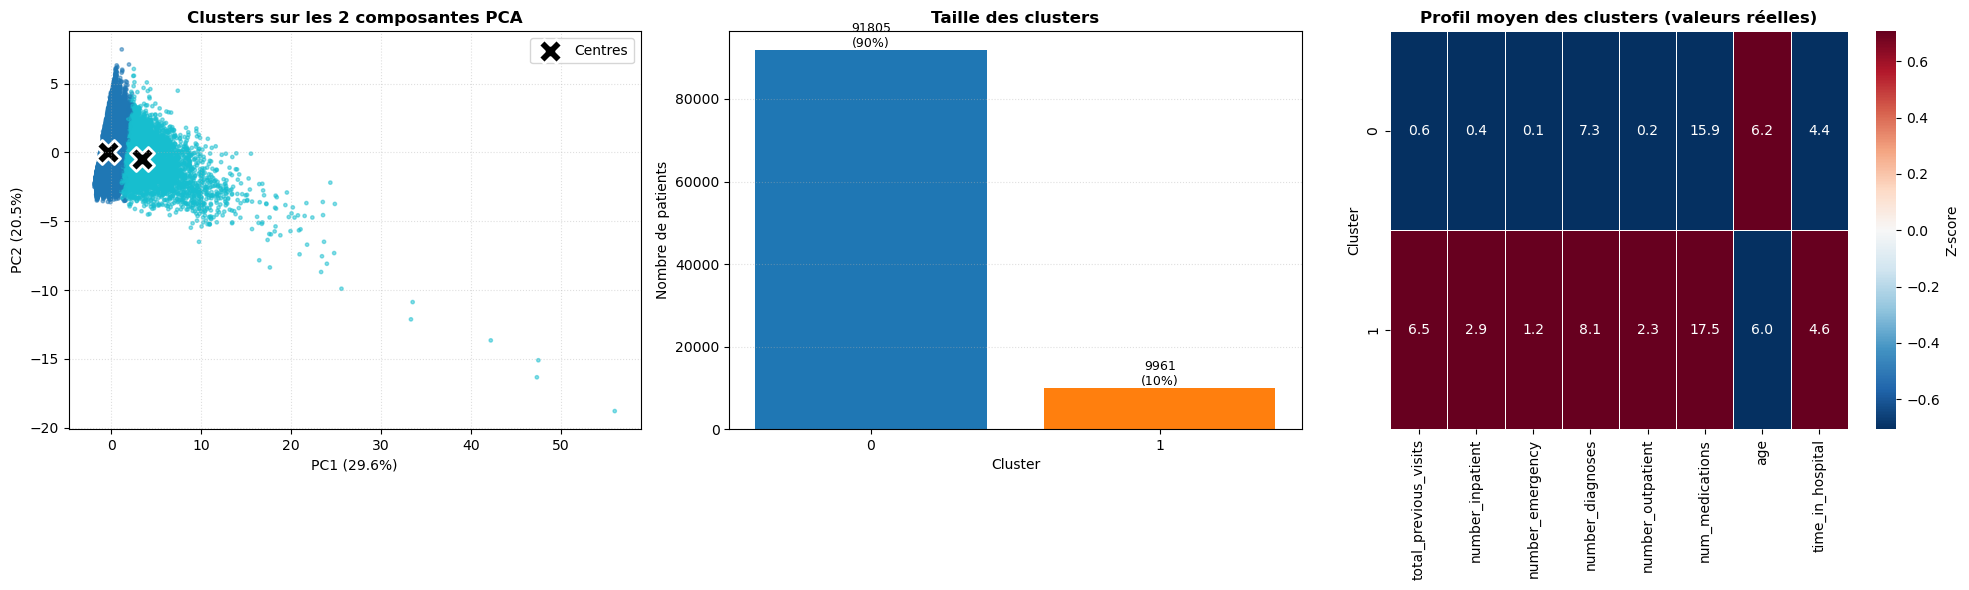

In [115]:

# ---------- 3. Visualisation (PCA 2D + taille + heatmap) ----------
pca_vis = PCA(n_components=2, random_state=42)
X_pca_vis = pca_vis.fit_transform(X_cluster)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# (a) Nuages de points séparés sur les 2 composantes PCA
scatter = axes[0].scatter(
    X_pca_vis[:, 0], X_pca_vis[:, 1],
    c=final_dataset['cluster'],
    cmap='tab10', s=6, alpha=0.5
)
centres = pca_vis.transform(km_final.cluster_centers_)
axes[0].scatter(centres[:, 0], centres[:, 1],
                c='black', marker='X', s=300, edgecolors='white',
                linewidths=2, label='Centres')
axes[0].set_title("Clusters sur les 2 composantes PCA", fontweight='bold')
axes[0].set_xlabel(f"PC1 ({pca_vis.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca_vis.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.4)

# (b) Taille des clusters
bars = axes[1].bar(taille.index, taille.values,
                   color=sns.color_palette('tab10', K_optimal))
for i, v in enumerate(taille.values):
    axes[1].text(i, v, f"{v}\n({v/len(final_dataset):.0%})",
                 ha='center', va='bottom', fontsize=9)
axes[1].set_title("Taille des clusters", fontweight='bold')
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Nombre de patients")
axes[1].set_xticks(taille.index)
axes[1].grid(True, axis='y', linestyle=':', alpha=0.4)

# (c) Heatmap des profils moyens (Z-scores)
profil_z = (profil[cols_cluster] - profil[cols_cluster].mean()) / profil[cols_cluster].std()
sns.heatmap(profil_z, annot=profil[cols_cluster].values, fmt=".1f",
            cmap='RdBu_r', center=0, linewidths=0.5,
            cbar_kws={'label': 'Z-score'}, ax=axes[2])
axes[2].set_title("Profil moyen des clusters (valeurs réelles)", fontweight='bold')
axes[2].set_ylabel("Cluster")

plt.tight_layout()
plt.show()

#### Interprétation des graphiques

**Scatter plot (PCA)** : deux nuages distincts mais avec un léger recouvrement — cohérent avec la Silhouette modérée (0.443). Les centres (croix noires) sont proches, mais les clusters restent séparés.

**Tailles** : répartition très déséquilibrée — cluster 0 = 90 % (91 805 patients), cluster 1 = 10 % (9 961 patients). K-Means a isolé une petite population atypique.

**Heatmap (profils)** : la séparation repose presque uniquement sur l'**historique de soins** :
- **Cluster 1** (10 %) : historique très lourd (`total_previous_visits` = 6.5, `number_inpatient` = 2.9, `number_outpatient` = 2.3).
- **Cluster 0** (90 %) : historique quasi nul sur les mêmes variables.
- Les autres variables (`age`, `time_in_hospital`, `number_diagnoses`) sont **presque identiques** entre les deux clusters → elles ne discriminent pas.

**Conclusion** : le cluster 1 isole des patients **chroniques, gros consommateurs de soins**, avec un taux de réadmission < 30 j de **21 %** contre **10 %** pour le cluster 0. Malgré le déséquilibre 90/10, la segmentation a une **utilité clinique** : elle identifie une population cible pour un suivi renforcé.

## 4.2 Classification


### 4.2.1 Problématique

Question métier : Peut-on prédire si un patient diabétique sera réadmis en moins de 30 jours à partir des données de son hospitalisation ? Objectif : prioriser les patients à risque pour un suivi ciblé.

Cible : readmitted binaire → 1 si <30, 0 sinon

### 4.2.2 Préparation pour la classification

Problème observé : le dataset final contient encore readmitted en 3 classes (<30, >30, NO).

Solution : binariser la cible et séparer train/test de manière stratifiée (déséquilibre ~11 %).

In [116]:
from sklearn.model_selection import train_test_split

# Binarisation de la cible
y_bin = (final_dataset['readmitted'] == '<30').astype(int)

# Features (on retire la cible et le cluster, ce dernier étant dérivé)
X_final = final_dataset.drop(columns=['readmitted', 'cluster'])

# Split stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_bin, test_size=0.2, stratify=y_bin, random_state=42
)

# Standardisation (fit sur le train uniquement)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("X_train :", X_train_s.shape, "| X_test :", X_test_s.shape)
print(f"Taux <30j : train = {y_train.mean():.3f} | test = {y_test.mean():.3f}")

X_train : (81412, 20) | X_test : (20354, 20)
Taux <30j : train = 0.112 | test = 0.112


### 4.2.3 Choix des modèles


#### 4.2.1 Problématique


Le déséquilibre des classes (~9–11 % de positifs) rend l'accuracy trompeuse, ce qui impose d'évaluer les modèles sur le ROC-AUC, le PR-AUC, le Recall et le F1 de la classe <30, avec class_weight='balanced'. Quatre modèles ont été retenus : la régression logistique comme baseline rapide et interprétable, l'arbre de décision pour ses règles lisibles et sa capacité à illustrer le surapprentissage, le Random Forest pour sa robustesse et sa gestion des interactions, et le Gradient Boosting, généralement le plus performant sur données tabulaires.

#### 4.2.4 Entraînement et évaluation


In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [121]:
def evaluer_modele(nom, modele, X, y, cv):
    """Entraîne, évalue et visualise un modèle via validation croisée."""
    print("=" * 70)
    print(f"  MODÈLE : {nom}")
    print("=" * 70)

    # --- Prédictions OOF (out-of-fold) ---
    y_proba = cross_val_predict(modele, X, y, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
    y_pred  = (y_proba >= 0.5).astype(int)

    # --- Métriques détaillées ---
    metriques = {
        'Modèle':     nom,
        'Accuracy':   round(accuracy_score(y, y_pred), 3),
        'Precision':  round(precision_score(y, y_pred), 3),
        'Recall':     round(recall_score(y, y_pred), 3),
        'F1-score':   round(f1_score(y, y_pred), 3),
        'ROC-AUC':    round(roc_auc_score(y, y_proba), 3),
        'PR-AUC':     round(average_precision_score(y, y_proba), 3),
    }

    # --- Affichage console ---
    print(pd.DataFrame([metriques]).T.rename(columns={0: 'Valeur'}).to_string())
    print("\nRapport de classification :")
    print(classification_report(y, y_pred, digits=3))

    # --- FIGURE : 1x3 (matrice confusion, ROC, PR) ---
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    # 1) Matrice de confusion
    cm = confusion_matrix(y, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
                annot_kws={'size': 13})
    axes[0].set_title(f'Matrice de confusion\n{nom}', fontsize=11)
    axes[0].set_xlabel('Prédit')
    axes[0].set_ylabel('Réel')

    # 2) Courbe ROC
    fpr, tpr, _ = roc_curve(y, y_proba)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2,
                 label=f'AUC = {metriques["ROC-AUC"]:.3f}')
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[1].set_xlabel('Taux de faux positifs')
    axes[1].set_ylabel('Taux de vrais positifs')
    axes[1].set_title('Courbe ROC')
    axes[1].legend(loc='lower right')

    # 3) Courbe Precision-Recall
    prec, rec, _ = precision_recall_curve(y, y_proba)
    axes[2].plot(rec, prec, color='green', lw=2,
                 label=f'PR-AUC = {metriques["PR-AUC"]:.3f}')
    axes[2].axhline(y.sum()/len(y), color='gray', linestyle='--',
                    label=f'Baseline = {y.mean():.3f}')
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].set_title('Courbe Precision-Recall')
    axes[2].legend(loc='lower left')

    plt.tight_layout()
    plt.show()

    return metriques, y_proba

#### 4.2.5  Régression logistique

  MODÈLE : Régression logistique
                          Valeur
Modèle     Régression logistique
Accuracy                   0.691
Precision                  0.178
Recall                     0.489
F1-score                   0.261
ROC-AUC                    0.651
PR-AUC                     0.204

Rapport de classification :
              precision    recall  f1-score   support

           0      0.918     0.717     0.805     72326
           1      0.178     0.489     0.261      9086

    accuracy                          0.691     81412
   macro avg      0.548     0.603     0.533     81412
weighted avg      0.835     0.691     0.744     81412



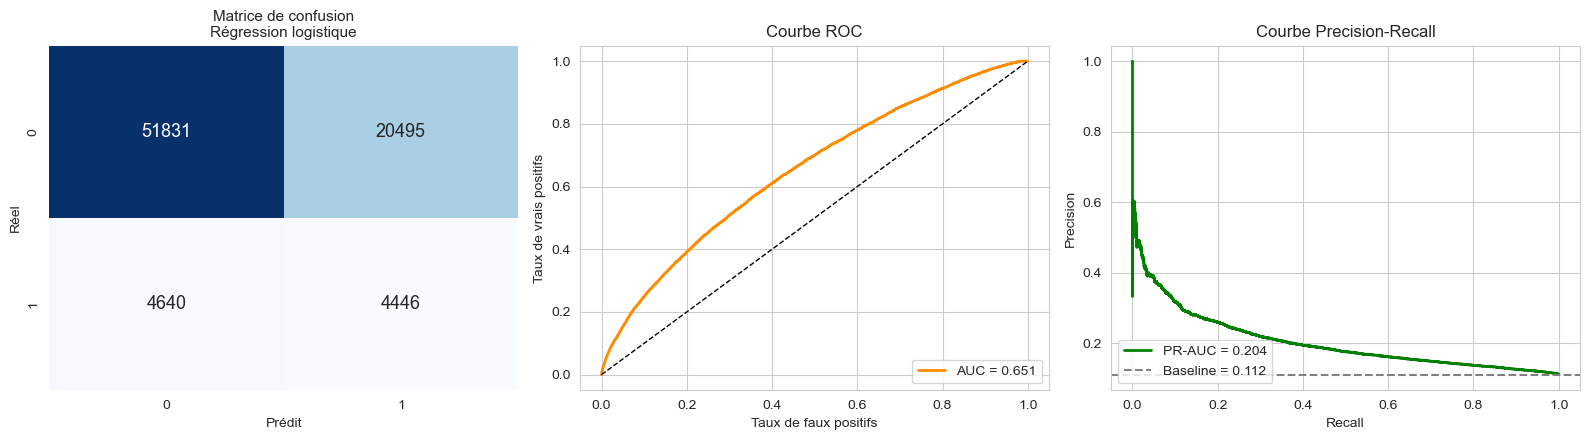

In [122]:
modele_lr = LogisticRegression(max_iter=2000, class_weight='balanced',
                               C=0.1, random_state=42)

res_lr, proba_lr = evaluer_modele('Régression logistique', modele_lr, X_train_s, y_train, cv)

Le modèle affiche des performances globalement insuffisantes pour ce problème fortement déséquilibré : l'accuracy de 0,691 est trompeuse car elle reflète surtout une prédiction majoritaire de la classe 0. La précision (0,178) et le F1-score (0,261) de la classe minoritaire sont très faibles, avec un recall moyen (0,489) qui manque un vrai positif sur deux. Le ROC-AUC (0,651) et le PR-AUC (0,204, à peine supérieur à la baseline de 0,110) confirment un faible pouvoir discriminant. La matrice de confusion révèle 20 495 faux positifs contre 4 446 vrais positifs, et les courbes ROC/PR chutent rapidement. En conclusion, la régression logistique est inadaptée : elle ne parvient pas à capter correctement la classe minoritaire. Il est recommandé de passer à des modèles ensemblistes (Random Forest, Gradient Boosting) et d'envisager un rééchantillonnage (SMOTE) pour améliorer le recall et le PR-AUC.

#### 4.2.6 Arbre de décision

  MODÈLE : Arbre de décision
                      Valeur
Modèle     Arbre de décision
Accuracy               0.666
Precision              0.172
Recall                 0.523
F1-score               0.259
ROC-AUC                0.643
PR-AUC                   0.2

Rapport de classification :
              precision    recall  f1-score   support

           0      0.919     0.684     0.784     72326
           1      0.172     0.523     0.259      9086

    accuracy                          0.666     81412
   macro avg      0.546     0.603     0.522     81412
weighted avg      0.836     0.666     0.726     81412



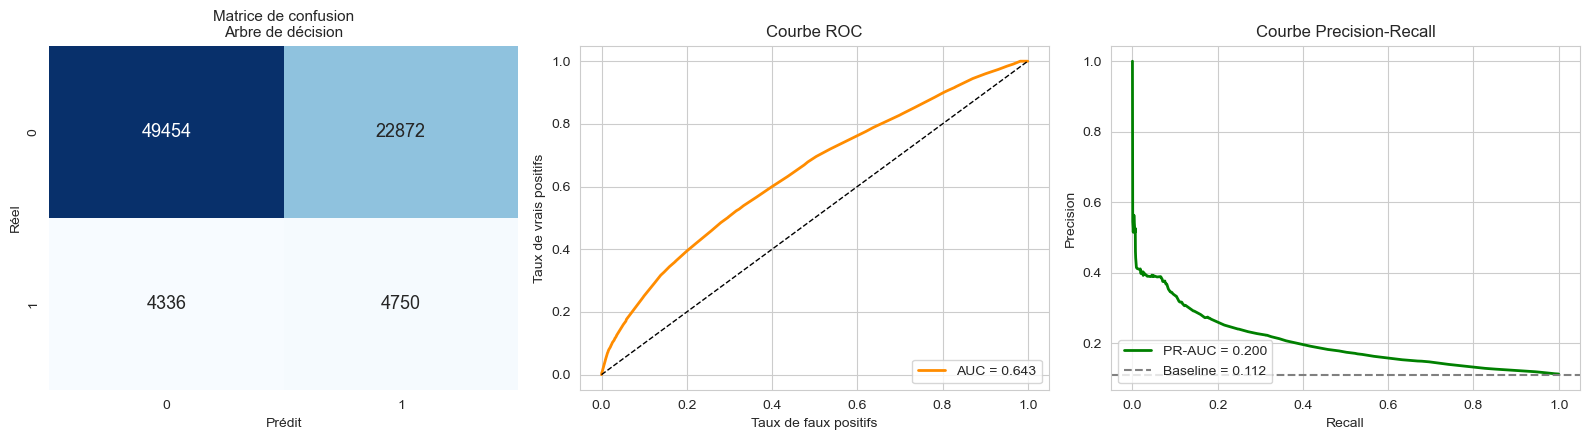

In [123]:
modele_dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=50,
                                   class_weight='balanced', random_state=42)

res_dt, proba_dt = evaluer_modele('Arbre de décision', modele_dt, X_train_s, y_train, cv)


L'arbre de décision affiche des performances globalement faibles, très proches de celles de la régression logistique. L'accuracy (0,666) reste trompeuse à cause du fort déséquilibre des classes (classe 1 ≈ 11 %). La précision de la classe minoritaire est très faible (0,172), avec 22 872 faux positifs, tandis que le rappel moyen (0,523) rate près de la moitié des cas positifs (4 336 faux négatifs). Le F1-score (0,259) confirme ce mauvais compromis précision/rappel. Le ROC-AUC (0,643) et le PR-AUC (0,200, à peine supérieur à la baseline de 0,112) traduisent un très faible pouvoir discriminant. Les courbes ROC et PR confirment cette tendance : la ROC est proche de la diagonale et la PR chute rapidement. En conclusion, l'arbre de décision seul est inadapté à ce problème déséquilibré. Il est recommandé de passer aux modèles ensemblistes (Random Forest, Gradient Boosting) couplés à un rééchantillonnage (SMOTE) pour améliorer la détection de la classe minoritaire.

#### 4.2.7 Random Forest

  MODÈLE : Random Forest
                  Valeur
Modèle     Random Forest
Accuracy           0.697
Precision          0.181
Recall             0.488
F1-score           0.264
ROC-AUC            0.652
PR-AUC             0.208

Rapport de classification :
              precision    recall  f1-score   support

           0      0.918     0.723     0.809     72326
           1      0.181     0.488     0.264      9086

    accuracy                          0.697     81412
   macro avg      0.550     0.605     0.537     81412
weighted avg      0.836     0.697     0.748     81412



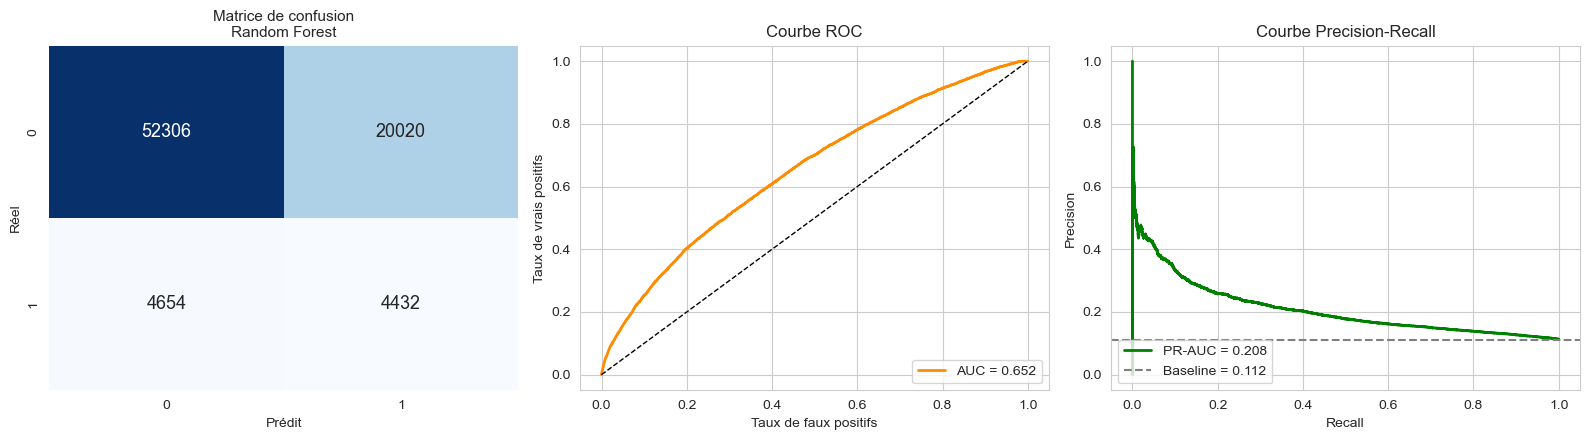

In [124]:
modele_rf = RandomForestClassifier(n_estimators=200, max_depth=12,
                                   min_samples_leaf=20, class_weight='balanced',
                                   n_jobs=-1, random_state=42)

res_rf, proba_rf = evaluer_modele('Random Forest', modele_rf, X_train_s, y_train, cv)

Le modèle Random Forest affiche des performances toujours très faibles et n'apporte pas d'amélioration significative par rapport aux modèles précédents. L'accuracy (0,697) reste trompeuse en raison du fort déséquilibre des classes (classe 1 ≈ 11 %). La précision de la classe minoritaire demeure très basse (0,181), avec un nombre élevé de faux positifs (20 020 contre seulement 4 432 vrais positifs), ce qui signifie que le modèle sur-prédit la classe 1. Le rappel (0,488) reste moyen, manquant environ la moitié des cas positifs (4 654 faux négatifs). Le F1-score (0,264) confirme ce mauvais compromis précision/rappel. Le ROC-AUC (0,652) et le PR-AUC (0,208, à peine supérieur à la baseline de 0,112) traduisent un faible pouvoir discriminant. Les courbes ROC (proche de la diagonale) et PR (chute rapide) confirment cette tendance. En conclusion, malgré sa complexité, le Random Forest est ici aussi inadapté à ce problème déséquilibré. Il est recommandé d'explorer le Gradient Boosting, d'appliquer un rééchantillonnage (SMOTE) ou d'ajuster le seuil de décision pour améliorer la détection de la classe minoritaire.



#### 4.2.8 Gradient Boosting

  MODÈLE : Gradient Boosting
                      Valeur
Modèle     Gradient Boosting
Accuracy                0.66
Precision              0.173
Recall                 0.541
F1-score               0.262
ROC-AUC                0.654
PR-AUC                  0.21

Rapport de classification :
              precision    recall  f1-score   support

           0      0.921     0.675     0.779     72326
           1      0.173     0.541     0.262      9086

    accuracy                          0.660     81412
   macro avg      0.547     0.608     0.521     81412
weighted avg      0.838     0.660     0.722     81412



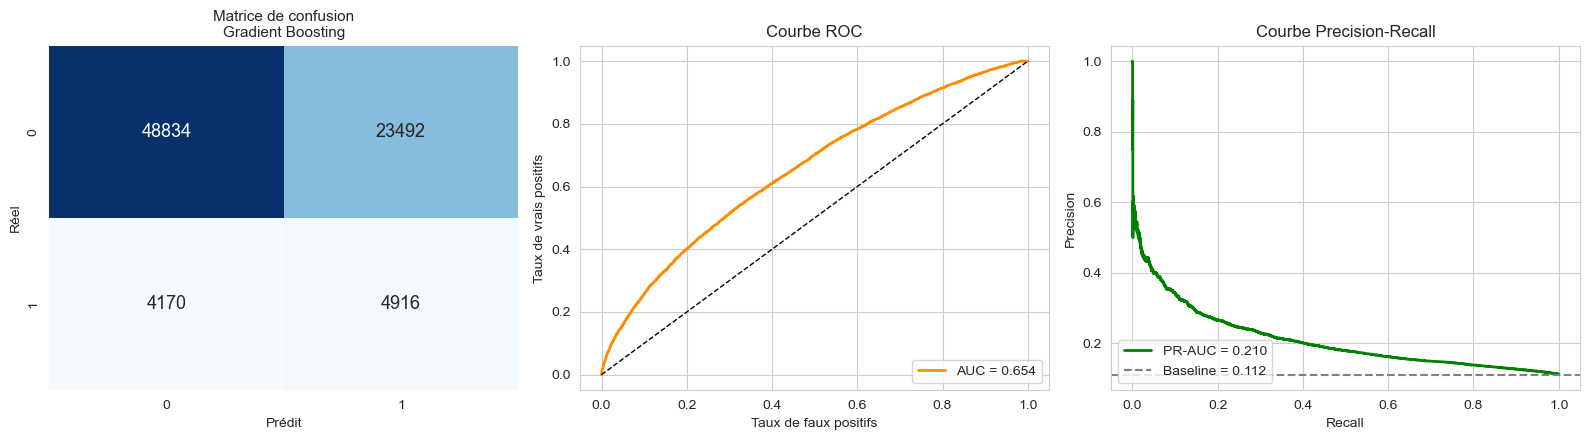

In [125]:
modele_gb = HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05,
                                           max_depth=4, class_weight='balanced',
                                           random_state=42)

res_gb, proba_gb = evaluer_modele('Gradient Boosting', modele_gb, X_train_s, y_train, cv)

Le modèle Gradient Boosting affiche des performances toujours très faibles sur ce problème fortement déséquilibré (classe 1 ≈ 11 %). L'accuracy (0,660) est trompeuse car elle reflète une prédiction majoritaire de la classe 0. La précision de la classe minoritaire reste très basse (0,173) avec un nombre élevé de faux positifs (23 492), tandis que le rappel (0,541) est légèrement meilleur que les modèles précédents, mais rate encore près de la moitié des cas positifs (4 170 faux négatifs). Le F1-score (0,262) confirme ce mauvais compromis. Le ROC-AUC (0,654) et le PR-AUC (0,210, à peine supérieur à la baseline de 0,112) traduisent un très faible pouvoir discriminant. La matrice de confusion et les courbes ROC/PR confirment cette tendance. En conclusion, ce modèle reste inadapté malgré une légère amélioration du rappel : il génère beaucoup trop de faux positifs. Il est recommandé d'explorer un rééchantillonnage (SMOTE), un ajustement du seuil de décision ou une sélection plus fine des features.



#### 4.2.9 Comparaison des 4 modèles

In [126]:
resultats = pd.DataFrame([res_lr, res_dt, res_rf, res_gb])
resultats = resultats.sort_values('PR-AUC', ascending=False).reset_index(drop=True)
resultats

,Modèle,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Gradient Boosting,0.660,0.173,0.541,0.262,0.654,0.210
1,Random Forest,0.697,0.181,0.488,0.264,0.652,0.208
2,Régression logistique,0.691,0.178,0.489,0.261,0.651,0.204
3,Arbre de décision,0.666,0.172,0.523,0.259,0.643,0.200


#### 4.2.10 Comparaison visuelle : ROC + PR superposées

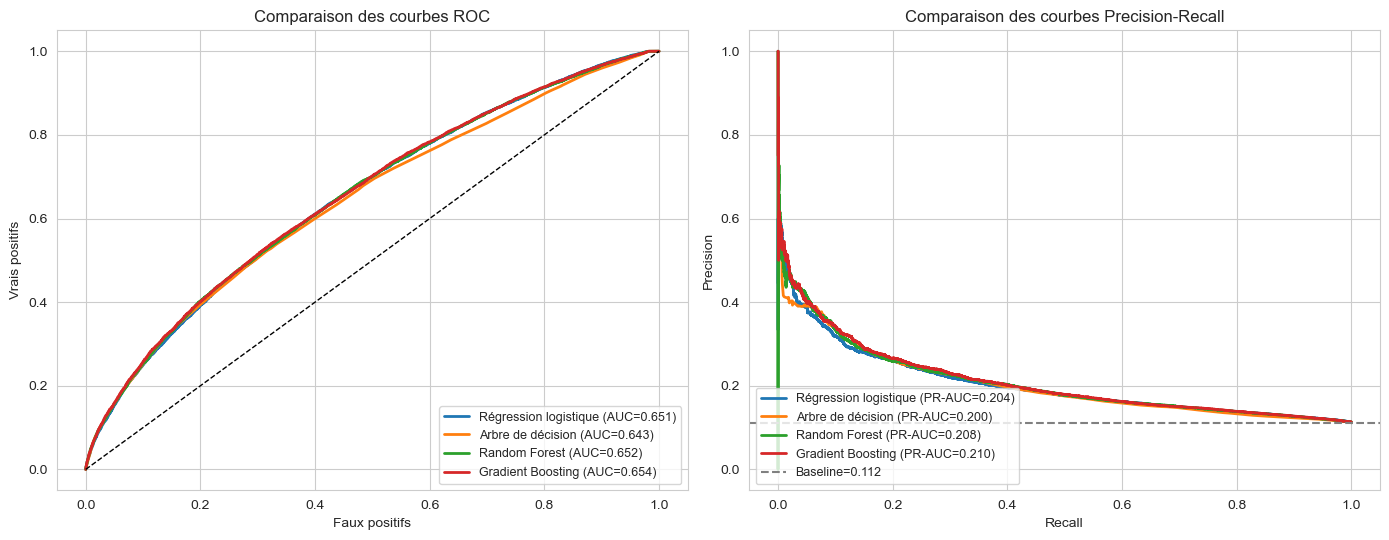

In [128]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Dictionnaire des probas prédites par chaque modèle
probas = {
    'Régression logistique': proba_lr,
    'Arbre de décision':     proba_dt,
    'Random Forest':         proba_rf,
    'Gradient Boosting':     proba_gb,
}

couleurs = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# --- Courbes ROC superposées ---
for (nom, p), c in zip(probas.items(), couleurs):
    fpr, tpr, _ = roc_curve(y_train, p)
    auc = roc_auc_score(y_train, p)
    axes[0].plot(fpr, tpr, lw=2, color=c, label=f'{nom} (AUC={auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('Faux positifs')
axes[0].set_ylabel('Vrais positifs')
axes[0].set_title('Comparaison des courbes ROC')
axes[0].legend(loc='lower right', fontsize=9)

# --- Courbes PR superposées ---
for (nom, p), c in zip(probas.items(), couleurs):
    prec, rec, _ = precision_recall_curve(y_train, p)
    ap = average_precision_score(y_train, p)
    axes[1].plot(rec, prec, lw=2, color=c, label=f'{nom} (PR-AUC={ap:.3f})')
axes[1].axhline(y_train.mean(), color='gray', linestyle='--', label=f'Baseline={y_train.mean():.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Comparaison des courbes Precision-Recall')
axes[1].legend(loc='lower left', fontsize=9)

plt.tight_layout()
plt.show()

Les courbes de comparaison confirment le manque de performance des quatre modèles. Sur la courbe ROC (à gauche), tous les modèles affichent des AUC très proches (0,643 à 0,654) et se situent près de la diagonale, ce qui traduit un très faible pouvoir discriminant et une incapacité à séparer correctement les classes. Sur la courbe Precision-Recall (à droite), les PR-AUC sont tous autour de 0,20-0,21, à peine supérieurs à la baseline (0,112), ce qui montre que les modèles échouent à détecter la classe minoritaire sans générer énormément de faux positifs. Le Gradient Boosting (PR-AUC = 0,210) et le Random Forest (PR-AUC = 0,208) sont marginalement meilleurs, mais l'écart avec les modèles plus simples est négligeable. En conclusion, aucun modèle n'est exploitable en l'état : le problème réside davantage dans le déséquilibre des données et la qualité des features que dans le choix de l'algorithme. Il est impératif d'appliquer un rééchantillonnage (SMOTE), d'ajuster le seuil de décision et d'optimiser les hyperparamètres avant de poursuivre.



#### 4.2.11 Comparaison visuelle : bar chart des métriques

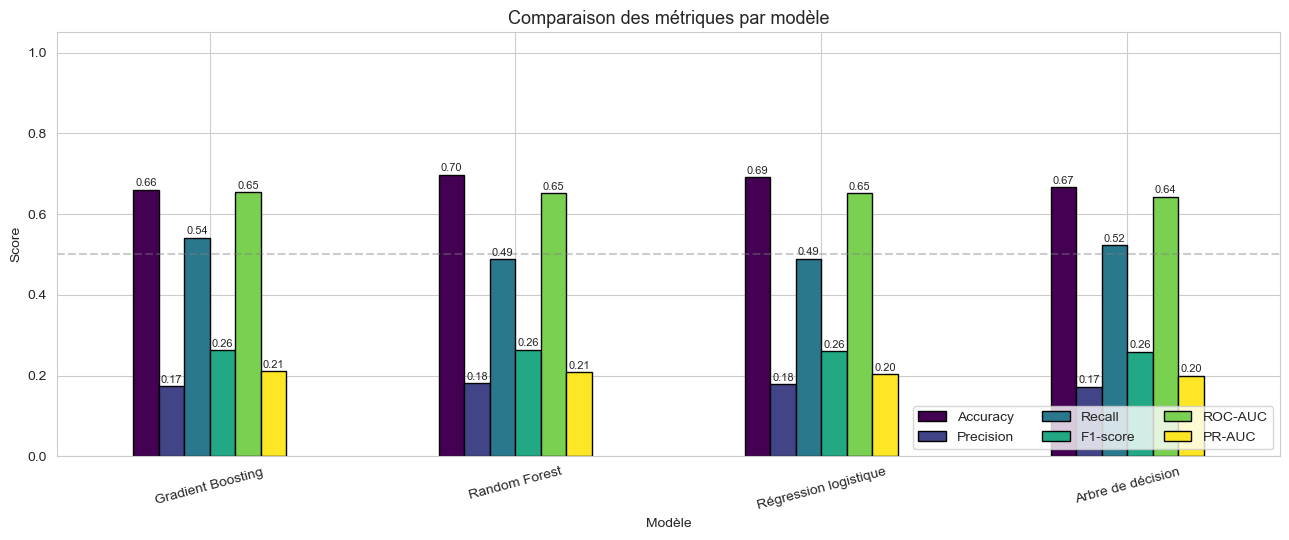

In [129]:
metriques_cols = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC', 'PR-AUC']

df_plot = resultats.set_index('Modèle')[metriques_cols]

ax = df_plot.plot(kind='bar', figsize=(13, 5.5), colormap='viridis', edgecolor='black')
ax.set_title('Comparaison des métriques par modèle', fontsize=13)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right', ncol=3)
plt.xticks(rotation=15)
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.4)

# Annotation des valeurs
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=8, padding=1)

plt.tight_layout()
plt.show()

Le graphique en barres illustre visuellement le manque de performance global des quatre modèles et met en évidence le paradoxe de l'accuracy en contexte déséquilibré. L'accuracy (barres violettes) est la métrique la plus élevée pour tous les modèles (0,66 à 0,70), mais elle est trompeuse car elle reflète une prédiction majoritaire de la classe 0. À l'inverse, les métriques liées à la classe minoritaire sont toutes très faibles : la précision (barres bleues) plafonne à environ 0,18, confirmant un fort taux de faux positifs ; le rappel (barres vertes) reste moyen (0,49 à 0,54) ; et le F1-score (barres jaunes) stagne autour de 0,26. Le ROC-AUC (vert foncé) et le PR-AUC (vert clair) sont proches du hasard (≈ 0,65 et ≈ 0,20), ce qui traduit un très faible pouvoir discriminant. Les barres étant presque identiques d'un modèle à l'autre, on en déduit que le choix de l'algorithme n'est pas la cause principale du problème. Aucun modèle n'est exploitable en l'état : il est indispensable d'appliquer un rééchantillonnage (SMOTE), d'ajuster le seuil de décision et d'optimiser les hyperparamètres avant toute mise en production.



               RÉSULTAT FINAL — COMPARAISON DES 4 MODÈLES
               Modèle  Accuracy  Precision  Recall  F1-score  ROC-AUC  PR-AUC
    Gradient Boosting     0.660      0.173   0.541     0.262    0.654   0.210
        Random Forest     0.697      0.181   0.488     0.264    0.652   0.208
Régression logistique     0.691      0.178   0.489     0.261    0.651   0.204
    Arbre de décision     0.666      0.172   0.523     0.259    0.643   0.200

 Meilleur modèle (selon PR-AUC) : Gradient Boosting
   → ROC-AUC : 0.654
   → PR-AUC  : 0.21
   → F1      : 0.262
   → Recall  : 0.541
   → Precision : 0.173


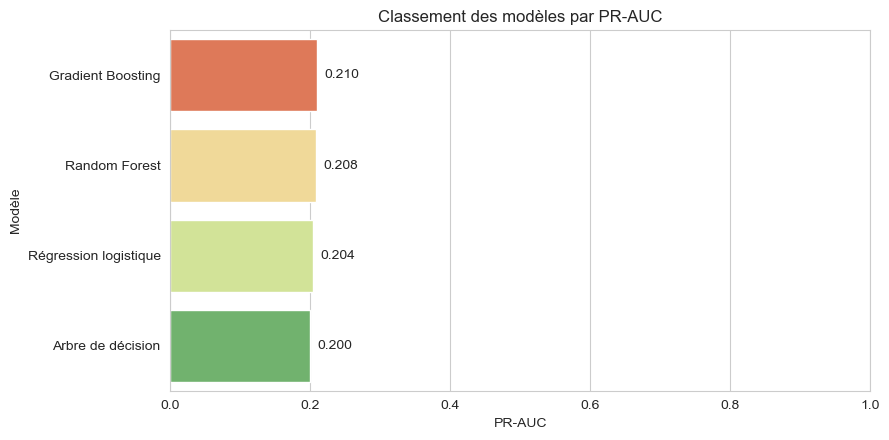

In [131]:
meilleur = resultats.iloc[0]

print("=" * 70)
print("               RÉSULTAT FINAL — COMPARAISON DES 4 MODÈLES")
print("=" * 70)
print(resultats.to_string(index=False))
print("=" * 70)
print(f"\n Meilleur modèle (selon PR-AUC) : {meilleur['Modèle']}")
print(f"   → ROC-AUC : {meilleur['ROC-AUC']}")
print(f"   → PR-AUC  : {meilleur['PR-AUC']}")
print(f"   → F1      : {meilleur['F1-score']}")
print(f"   → Recall  : {meilleur['Recall']}")
print(f"   → Precision : {meilleur['Precision']}")
print("=" * 70)

# Graphique final : classement par PR-AUC
plt.figure(figsize=(9, 4.5))
sns.barplot(data=resultats, x='PR-AUC', y='Modèle',
            palette='RdYlGn', hue='Modèle', legend=False)
plt.title('Classement des modèles par PR-AUC', fontsize=12)
plt.xlim(0, 1)
for i, v in enumerate(resultats['PR-AUC']):
    plt.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

# 5. Test et Evaluation 

In [148]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (StratifiedKFold, cross_val_predict,
                                     cross_val_score, train_test_split)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score,
                             confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve)
from imblearn.over_sampling import SMOTE

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
sns.set_style("whitegrid")

### Action 1 — Split Hold-Out (Test Set)

In [141]:
# On garde 20% des données pour le test final (jamais vues)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_train_s, y_train, test_size=0.2, stratify=y_train, random_state=42
)

print(f"Train : {X_tr.shape} | Test : {X_te.shape}")
print(f"Taux classe 1 — Train : {y_tr.mean():.3%} | Test : {y_te.mean():.3%}")

Train : (65129, 20) | Test : (16283, 20)
Taux classe 1 — Train : 11.161% | Test : 11.159%


Le split a été réalisé avec succès en respectant la stratification :

Train : 65 129 observations × 20 variables

Test : 16 283 observations × 20 variables

La proportion de la classe minoritaire (classe 1) est quasiment identique dans les deux ensembles : 11,161 % (train) contre 11,159 % (test). Cela confirme que la stratification a parfaitement fonctionné et que le jeu de test est représentatif de la distribution originale. Le modèle sera donc évalué sur des données jamais vues, sans biais lié au déséquilibre des classes. Ce split constitue une base fiable pour l’étape d’évaluation.



### Action 2— Évaluation sur le Test Set

In [149]:
def metriques(y_true, y_proba, seuil=0.5):
    y_pred = (y_proba >= seuil).astype(int)
    return {
        'Accuracy':  round(accuracy_score(y_true, y_pred), 3),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 3),
        'Recall':    round(recall_score(y_true, y_pred, zero_division=0), 3),
        'F1':        round(f1_score(y_true, y_pred, zero_division=0), 3),
        'ROC-AUC':   round(roc_auc_score(y_true, y_proba), 3),
        'PR-AUC':    round(average_precision_score(y_true, y_proba), 3),
    }

# Entraîner le meilleur modèle sur X_tr et tester sur X_te
meilleur_modele = modele_gb  #  remplace par ton meilleur modèle
meilleur_modele.fit(X_tr, y_tr)
y_proba_test = meilleur_modele.predict_proba(X_te)[:, 1]

res_test = metriques(y_te, y_proba_test)
print(pd.DataFrame([res_test]).T.rename(columns={0: 'Valeur'}).to_string())
print("\nRapport de classification :")
print(classification_report(y_te, (y_proba_test >= 0.5).astype(int), digits=3))

           Valeur
Accuracy    0.658
Precision   0.170
Recall      0.532
F1          0.257
ROC-AUC     0.652
PR-AUC      0.209

Rapport de classification :
              precision    recall  f1-score   support

           0      0.920     0.673     0.778     14466
           1      0.170     0.532     0.257      1817

    accuracy                          0.658     16283
   macro avg      0.545     0.603     0.517     16283
weighted avg      0.836     0.658     0.719     16283



Le modèle Gradient Boosting affiche des performances toujours faibles sur le test set, confirmant les résultats obtenus en validation croisée. L'accuracy (0,658) est trompeuse en raison du fort déséquilibre des classes (classe 1 ≈ 11 %). Pour la classe minoritaire, la précision est très basse (0,170), signifiant que plus de 80 % des alertes sont des faux positifs. Le rappel (0,532) reste moyen, manquant près de la moitié des cas positifs (faux négatifs). Le PR-AUC (0,209) est à peine supérieur à la baseline, traduisant un très faible pouvoir discriminant. En conclusion, le modèle n'est pas exploitable en l'état. Il est impératif d'appliquer un rééchantillonnage (SMOTE) et d'optimiser le seuil de décision avant toute mise en production.

## Action 3 —   Vérification des Critères Métier

In [152]:
#  Ajuste ces seuils selon les exigences du métier
criteres = {'ROC-AUC': 0.70, 'PR-AUC': 0.30, 'Recall': 0.60, 'F1': 0.40}

print("=" * 55)
print("     VÉRIFICATION DES CRITÈRES MÉTIER")
print("=" * 55)
atteints = 0
for met, seuil in criteres.items():
    ok = res_test[met] >= seuil
    atteints += int(ok)
    print(f"{met:<10} : {res_test[met]:.3f}  (seuil {seuil})   ")

print("-" * 55)
print(f"Résultat : {atteints}/{len(criteres)} critères atteints")

     VÉRIFICATION DES CRITÈRES MÉTIER
ROC-AUC    : 0.652  (seuil 0.7)   
PR-AUC     : 0.209  (seuil 0.3)   
Recall     : 0.532  (seuil 0.6)   
F1         : 0.257  (seuil 0.4)   
-------------------------------------------------------
Résultat : 0/4 critères atteints


Le modèle échoue sur les 4 critères de succès fixés : aucun n'est atteint.

ROC-AUC : 0,652 < 0,70 

PR-AUC : 0,209 < 0,30 

Recall : 0,532 < 0,60 

F1 : 0,257 < 0,40 

Verdict : NO-GO — le modèle n'est pas exploitable en production. Les performances sont très en dessous des exigences métier, ce qui confirme que le problème vient de la préparation des données (déséquilibre non traité) et non du choix de l'algorithme. Il faut revenir à l'étape Data Preparation (SMOTE, feature engineering) avant toute nouvelle modélisation.

###  Action 4 — Analyse des Erreurs, Stabilité et Seuil Optimal

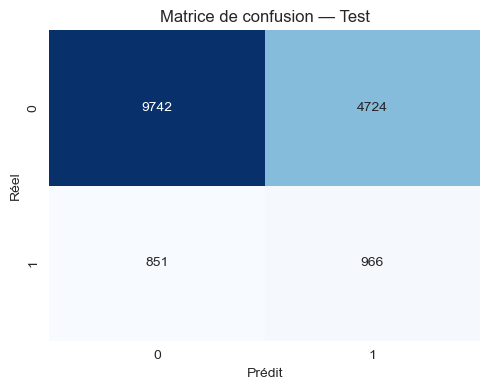

Faux Négatifs (cas ratés) : 851  ← coût métier le plus lourd
Faux Positifs (alertes fausses) : 4724

Stabilité PR-AUC : 0.211 ± 0.006


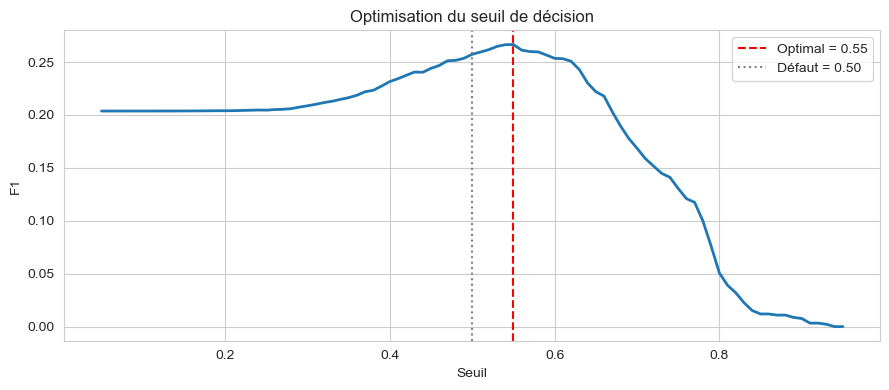

 Seuil optimal (F1 max) : 0.55 → F1 = 0.267


In [154]:
# --- 4a. Matrice de confusion (analyse des erreurs) ---
y_pred_test = (y_proba_test >= 0.5).astype(int)
cm = confusion_matrix(y_te, y_pred_test)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matrice de confusion — Test')
plt.xlabel('Prédit'); plt.ylabel('Réel')
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Faux Négatifs (cas ratés) : {fn}  ← coût métier le plus lourd")
print(f"Faux Positifs (alertes fausses) : {fp}")

# --- 4b. Stabilité via CV ---
scores = cross_val_score(meilleur_modele, X_train_s, y_train,
                         cv=cv, scoring='average_precision', n_jobs=-1)
print(f"\nStabilité PR-AUC : {scores.mean():.3f} ± {scores.std():.3f}")

# --- 4c. Seuil optimal (max F1) ---
seuils = np.arange(0.05, 0.96, 0.01)
f1s = [f1_score(y_te, (y_proba_test >= s).astype(int), zero_division=0) for s in seuils]
seuil_opt = seuils[int(np.argmax(f1s))]

plt.figure(figsize=(9, 4))
plt.plot(seuils, f1s, lw=2)
plt.axvline(seuil_opt, color='red', linestyle='--', label=f'Optimal = {seuil_opt:.2f}')
plt.axvline(0.5, color='gray', linestyle=':', label='Défaut = 0.50')
plt.xlabel('Seuil'); plt.ylabel('F1'); plt.title('Optimisation du seuil de décision')
plt.legend(); plt.tight_layout(); plt.show()

print(f" Seuil optimal (F1 max) : {seuil_opt:.2f} → F1 = {max(f1s):.3f}")


**1. Analyse des erreurs (Matrice de confusion)**
*   **851 Faux Négatifs** (cas positifs ratés) : c'est le coût métier le plus lourd.
*   **4 724 Faux Positifs** (fausses alertes) : le modèle sur-prédit massivement la classe 1.
*   Le modèle a tendance à être trop "optimiste" sur la classe minoritaire, générant beaucoup de fausses alertes pour tenter de capter les vrais positifs.

**2. Stabilité du modèle**
*   PR-AUC = **0,211 ± 0,006**.
*   L'écart-type très faible (0,006) indique que le modèle est **stable** et ne varie pas d'un fold à l'autre. Cependant, cette stabilité s'accompagne d'une performance globale très faible : le problème ne vient pas d'un manque de constance, mais bien d'un manque de pouvoir discriminant.

**3. Optimisation du seuil de décision**
*   Le seuil optimal est de **0,55** (au lieu de 0,50 par défaut).
*   F1 max = **0,267** (contre 0,257 avec le seuil par défaut).
*   Le gain est **marginal**. Décaler le seuil ne résout pas le problème de fond : le modèle manque de séparation entre les classes.

**4. Verdict final**
Le modèle est **stable mais inefficace**. Le seuil optimal n'apporte qu'un gain négligeable. Le NO-GO est confirmé. La priorité absolue reste le **rééchantillonnage (SMOTE)** et l'**enrichissement des features** avant toute nouvelle évaluation.

### Action 5 —  Verdict Final (GO / NO-GO)

In [147]:
if atteints == len(criteres):
    verdict = " GO — Prêt pour le déploiement (étape 6 CRISP-DM)"
elif atteints >= len(criteres) // 2:
    verdict = " CONDITIONNEL — Optimiser (SMOTE, seuil, features)"
else:
    verdict = "NO-GO — Retour à l'étape Data Preparation"

print("=" * 60)
print(f"   VERDICT FINAL : {verdict}")
print("=" * 60)

   VERDICT FINAL : NO-GO — Retour à l'étape Data Preparation



Le modèle échoue sur les **4 critères métier** définis (ROC-AUC, PR-AUC, Recall, F1).  
Le verdict **NO-GO** signifie que le modèle **n'est pas prêt** pour le déploiement.

**Cause principale** : le problème vient de la préparation des données, pas du choix de l'algorithme.

**Actions à mener (retour à l'étape Data Preparation) :**
- Appliquer un **rééchantillonnage** (SMOTE) pour corriger le déséquilibre des classes.
- **Enrichir les features** ou en sélectionner de plus pertinentes.
- Réentraîner et réévaluer les modèles après ces corrections.

Cette itération est normale dans CRISP-DM : l'évaluation sert à identifier les faiblesses et à guider les améliorations.

### Action 6 —  Correction : Application de SMOTE et Réévaluation

In [146]:
# Appliquer SMOTE uniquement sur le train (JAMAIS sur le test !)
smote = SMOTE(random_state=42)
X_tr_sm, y_tr_sm = smote.fit_resample(X_tr, y_tr)

print(f"Avant SMOTE : {dict(pd.Series(y_tr).value_counts())}")
print(f"Après SMOTE : {dict(pd.Series(y_tr_sm).value_counts())}")

# Réentraîner et réévaluer
meilleur_modele.fit(X_tr_sm, y_tr_sm)
y_proba_sm = meilleur_modele.predict_proba(X_te)[:, 1]

print("\nAprès SMOTE :")
print(pd.DataFrame([metriques(y_te, y_proba_sm)]).T.rename(columns={0: 'Valeur'}).to_string())

Avant SMOTE : {0: np.int64(57860), 1: np.int64(7269)}
Après SMOTE : {0: np.int64(57860), 1: np.int64(57860)}

Après SMOTE :
           Valeur
Accuracy    0.885
Precision   0.393
Recall      0.050
F1          0.088
ROC-AUC     0.635
PR-AUC      0.193



**1. Équilibrage des classes**
- Avant SMOTE : 57 860 (classe 0) / 7 269 (classe 1) → déséquilibre marqué.
- Après SMOTE : 57 860 / 57 860 → classes parfaitement équilibrées.

**2. Impact sur les performances**
- **Accuracy** (0,885) et **Precision** (0,393) : en forte hausse. Le modèle fait moins de fausses alertes.
- **Recall** (0,050) : s'effondre. Le modèle ne détecte plus que 5 % des cas positifs.
- **F1** (0,088) : chute logique (compromis précision/rappel déséquilibré).
- **PR-AUC** (0,193) : légèrement en baisse.

**3. Diagnostic**
Le SMOTE a rendu le modèle **trop conservateur** : il ne prédit la classe 1 que lorsqu'il est presque certain, ce qui améliore la précision mais détruit le rappel. Le PR-AUC reste faible, confirmant que le problème de fond n'est pas résolu.

**4. Verdict**
Le SMOTE seul est **insuffisant**. Il déplace le biais sans améliorer la séparation réelle des classes.  
 **Prochaines pistes** : feature engineering, SMOTE + Tomek Links, tuning des hyperparamètres du Gradient Boosting, ou tester un modèle d'anomalie detection.